
# **Problem Statement**

**Late Delivery Prediction in Supply Chain and Logistics**

Late deliveries can negatively impact customer satisfaction, operational efficiency, and overall supply chain performance. The objective of this project is to develop a machine learning model that predicts whether an order is likely to be delivered late, based on factors such as shipping details, order characteristics, product information, customer and geographical attributes, and temporal patterns.

The project aims to identify the key factors influencing delivery delays and develop a reliable predictive model that can help businesses anticipate late deliveries and take proactive measures to improve logistics and customer service.

**Modelling Approach**

To compare the performance of different machine learning approaches, the modelling process will be carried out through two separate preprocessing pipelines:

*1.Tree-Based Models*

Models such as LightGBM will be developed using preprocessing suitable for tree-based algorithms, which generally do not require feature scaling.

*2.Linear & Distance-Based Models*

Logistic Regression and SVM will be developed using a separate preprocessing pipeline involving appropriate encoding and feature scaling, since these algorithms are sensitive to feature magnitude.

This two-way modelling approach allows us to compare tree-based and non-tree-based algorithms fairly while applying preprocessing techniques appropriate to the characteristics of each model.

#**DATA UNDERSTANDING**

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import joblib
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import chardet

file_path = "/content/drive/MyDrive/Team6/data/DataCoSupplyChainDataset.csv"

with open(file_path, "rb") as f:
    result = chardet.detect(f.read(100000))

print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [4]:
#reading dataset
data = pd.read_csv(file_path, encoding=result['encoding'])

In [5]:
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


The dataset contains 52 columns and 180519 rows.

The dates are not in the datetime format.The columns is converted into datetime format and then splitted into 'Months','Day','Day of week,'Year Month','Month Name' for EDA

In [6]:
data.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# EDA

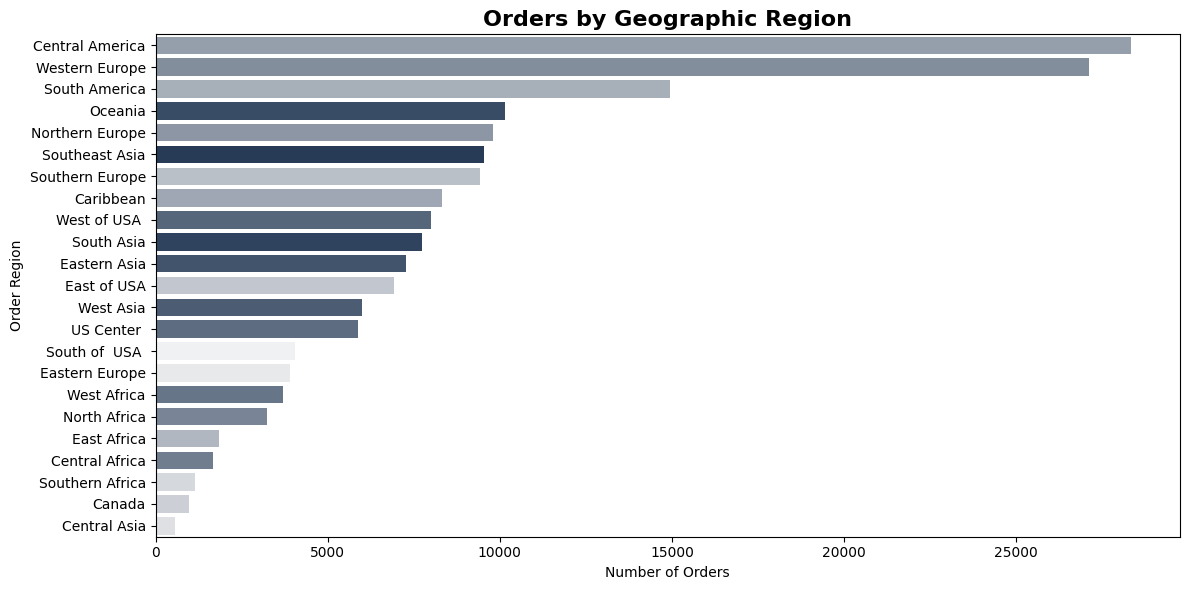

In [7]:
plt.figure(figsize=(12, 6))
# Order regions by frequency
order = data['Order Region'].value_counts().index

# Create dark-to-light navy gradient
colors = sns.light_palette(
    "#1F3A5F",
    n_colors=len(order),
    reverse=True
)

sns.countplot(
    y='Order Region',
    data=data,
    order=order,
    palette=colors,
    hue='Order Region',
    legend=False
)

plt.title(
    "Orders by Geographic Region",
    fontsize=16,fontweight='bold'

)

plt.xlabel("Number of Orders")
plt.ylabel("Order Region")

plt.tight_layout()
plt.show()

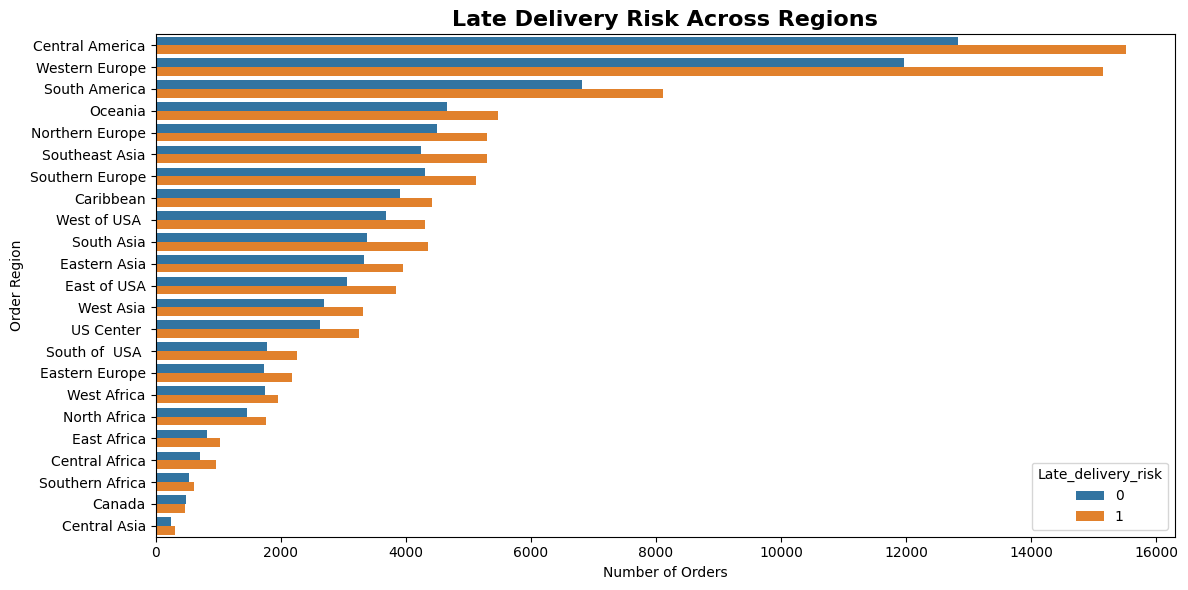

In [8]:
# Late Delivery Risk Across Regions

plt.figure(figsize=(12, 6))

# Sort regions by total number of orders
region_order = (
    data['Order Region']
    .value_counts()
    .index
)

sns.countplot(
    y='Order Region',
    hue='Late_delivery_risk',
    data=data,
    order=region_order
)

plt.title(
    "Late Delivery Risk Across Regions",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Orders")
plt.ylabel("Order Region")

plt.tight_layout()
plt.show()

In [9]:
# Counts of Late Delivery Risk by Order Region

region_risk_counts = (
    data.groupby(['Order Region', 'Late_delivery_risk'])
    .size()
    .unstack(fill_value=0)
)

# Rename columns
region_risk_counts.columns = [
    'On-Time / Low Risk',
    'Late Risk'
]

# Add total orders
region_risk_counts['Total Orders'] = (
    region_risk_counts['On-Time / Low Risk'] +
    region_risk_counts['Late Risk']
)

# Sort by total number of orders
region_risk_counts = region_risk_counts.sort_values(
    'Total Orders',
    ascending=False
)

print(region_risk_counts)

                 On-Time / Low Risk  Late Risk  Total Orders
Order Region                                                
Central America               12823      15518         28341
Western Europe                11969      15140         27109
South America                  6824       8111         14935
Oceania                        4666       5482         10148
Northern Europe                4500       5292          9792
Southeast Asia                 4242       5297          9539
Southern Europe                4302       5129          9431
Caribbean                      3903       4415          8318
West of USA                    3680       4313          7993
South Asia                     3381       4350          7731
Eastern Asia                   3325       3955          7280
East of USA                    3066       3849          6915
West Asia                      2687       3322          6009
US Center                      2635       3252          5887
South of  USA           

In [10]:
region_risk_counts['Late Risk %'] = (
    region_risk_counts['Late Risk'] /
    region_risk_counts['Total Orders'] * 100
)

print(region_risk_counts.round(2))

                 On-Time / Low Risk  Late Risk  Total Orders  Late Risk %
Order Region                                                             
Central America               12823      15518         28341        54.75
Western Europe                11969      15140         27109        55.85
South America                  6824       8111         14935        54.31
Oceania                        4666       5482         10148        54.02
Northern Europe                4500       5292          9792        54.04
Southeast Asia                 4242       5297          9539        55.53
Southern Europe                4302       5129          9431        54.38
Caribbean                      3903       4415          8318        53.08
West of USA                    3680       4313          7993        53.96
South Asia                     3381       4350          7731        56.27
Eastern Asia                   3325       3955          7280        54.33
East of USA                    3066   

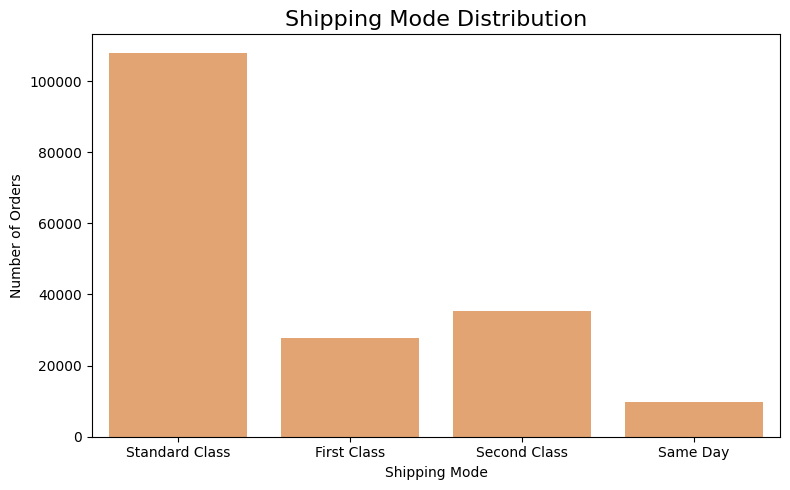

In [11]:
# Shipping Mode Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    x='Shipping Mode',
    data=data,
    color="#F4A261"
)

plt.title(
    "Shipping Mode Distribution",
    fontsize=16,

)

plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

#plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

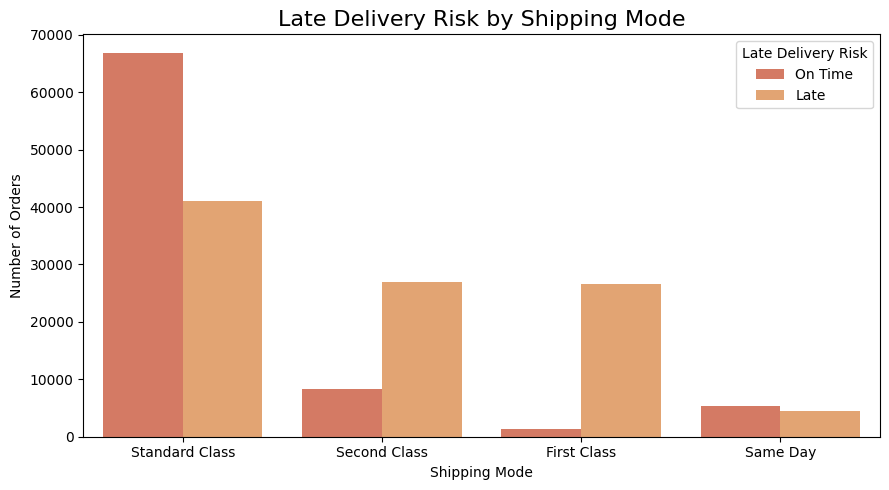

In [12]:
# Late Delivery Risk Distribution by Shipping Mode

plt.figure(figsize=(9, 5))

# Order shipping modes by total number of orders
shipping_order = (
    data['Shipping Mode']
    .value_counts()
    .index
)

# Two shades of the same orange palette
colors = ["#E76F51", "#F4A261"]

sns.countplot(
    x='Shipping Mode',
    hue='Late_delivery_risk',
    data=data,
    order=shipping_order,
    palette=colors
)

plt.title(
    "Late Delivery Risk by Shipping Mode",
    fontsize=16
)

plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

#plt.xticks(rotation=30)

plt.legend(
    title="Late Delivery Risk",
    labels=["On Time", "Late"]
)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Late Delivery Risk by Shipping Mode - Count & Percentage
# ============================================================

# Count of orders
shipping_risk = (
    data.groupby(['Shipping Mode', 'Late_delivery_risk'])
    .size()
    .unstack(fill_value=0)
)

# Rename columns
shipping_risk.columns = [
    'On Time / Low Risk',
    'Late Risk'
]

# Total orders for each shipping mode
shipping_risk['Total Orders'] = shipping_risk.sum(axis=1)

# Late-risk percentage
shipping_risk['Late Risk %'] = (
    shipping_risk['Late Risk']
    / shipping_risk['Total Orders']
    * 100
)

# On-time / low-risk percentage
shipping_risk['On Time / Low Risk %'] = (
    shipping_risk['On Time / Low Risk']
    / shipping_risk['Total Orders']
    * 100
)

# Sort by total orders
shipping_risk = shipping_risk.sort_values(
    'Total Orders',
    ascending=False
)

# Display
print(shipping_risk.round(2))

                On Time / Low Risk  Late Risk  Total Orders  Late Risk %  \
Shipping Mode                                                              
Standard Class               66729      41023        107752        38.07   
Second Class                  8229      26987         35216        76.63   
First Class                   1301      26513         27814        95.32   
Same Day                      5283       4454          9737        45.74   

                On Time / Low Risk %  
Shipping Mode                         
Standard Class                 61.93  
Second Class                   23.37  
First Class                     4.68  
Same Day                       54.26  



*   First Class has the highest late-delivery risk, with 95.32% of its 27,814 orders classified as late risk (26,513 orders).
*   Second Class also shows a very high late-risk rate of 76.63%, with 26,987 late-risk orders out of 35,216.

*   Standard Class performs considerably better, with the lowest late-risk rate among the major shipping modes at 38.07%. It also has the largest order volume (107,752 orders) and 66,729 on-time/low-risk orders.
*   Same Day has a 45.74% late-risk rate, with 4,454 late-risk orders out of 9,737.

*   Overall, faster shipping modes do not necessarily correspond to lower late-delivery risk in this dataset. In fact, First Class has the highest risk, suggesting that factors beyond the selected shipping mode may be contributing to delivery delays.



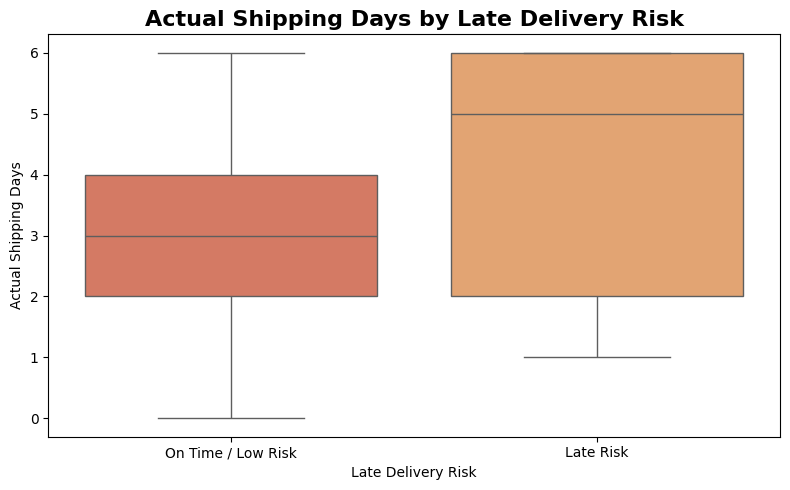

In [14]:
# Actual Shipping Days by Late Delivery Risk
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Late_delivery_risk',
    y='Days for shipping (real)',
    data=data,
    palette=["#E76F51", "#F4A261"]
)

plt.title(
    "Actual Shipping Days by Late Delivery Risk",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Late Delivery Risk")
plt.ylabel("Actual Shipping Days")

plt.xticks(
    [0, 1],
    ["On Time / Low Risk", "Late Risk"]
)

plt.tight_layout()
plt.show()



*   On-Time / Low Risk orders have a median actual shipping time of about 3 days.
*   Late-risk orders have a much higher median of about 5 days.

*   For low-risk orders, the middle 50% of observations lies approximately between 2 and 4 days.
*   For late-risk orders, the middle 50% extends from approximately 2 to 6 days, indicating greater variation in actual shipping time.


*   The distributions overlap, particularly around 2–4 days, so actual shipping time alone does not perfectly distinguish late from on-time orders.
*   The distributions overlap, particularly around 2–4 days, so actual shipping time alone does not perfectly distinguish late from on-time orders.

*   Overall, orders taking longer to ship are more strongly associated with late-delivery risk.












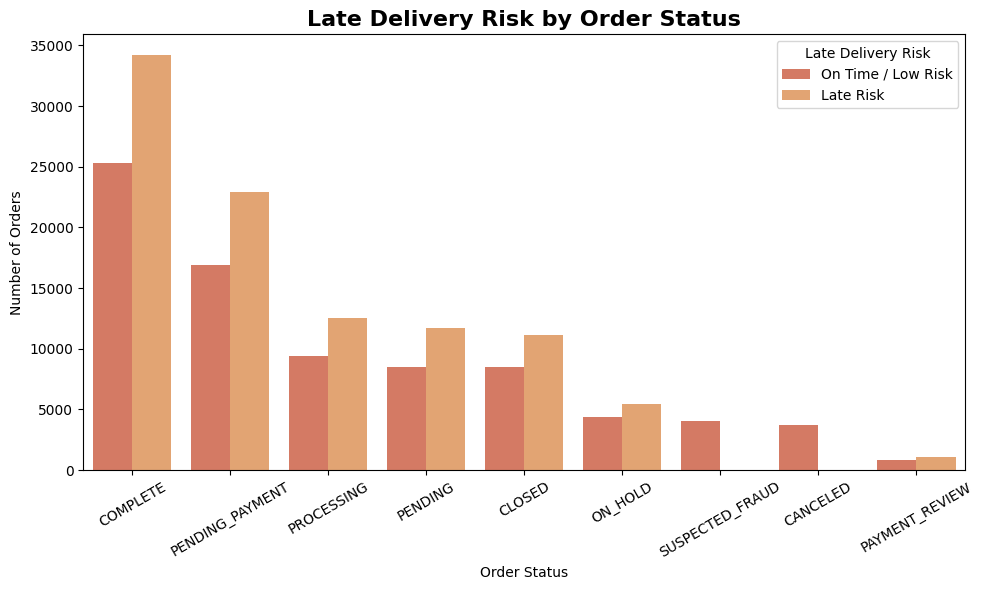

In [15]:
# Late Delivery Risk by Order Status

plt.figure(figsize=(10, 6))

# Sort Order Status by total number of orders
status_order = (
    data['Order Status']
    .value_counts()
    .index
)

# Two shades of the same orange palette
colors = ["#E76F51", "#F4A261"]

sns.countplot(
    x='Order Status',
    hue='Late_delivery_risk',
    data=data,
    order=status_order,
    palette=colors
)

plt.title(
    "Late Delivery Risk by Order Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.legend(
    title="Late Delivery Risk",
    labels=["On Time / Low Risk", "Late Risk"]
)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Order Status - Late Delivery Risk Count & Percentage
# ============================================================

shipping_risk = (
    data.groupby(['Order Status', 'Late_delivery_risk'])
    .size()
    .unstack(fill_value=0)
)

# Rename risk columns
shipping_risk = shipping_risk.rename(
    columns={
        0: 'On Time / Low Risk',
        1: 'Late Risk'
    }
)

# Total orders for each shipping mode
shipping_risk['Total Orders'] = (
    shipping_risk['On Time / Low Risk'] +
    shipping_risk['Late Risk']
)

# Percentage of On-Time / Low Risk
shipping_risk['On Time / Low Risk %'] = (
    shipping_risk['On Time / Low Risk']
    / shipping_risk['Total Orders']
    * 100
)

# Percentage of Late Risk
shipping_risk['Late Risk %'] = (
    shipping_risk['Late Risk']
    / shipping_risk['Total Orders']
    * 100
)

# Sort by total order count
shipping_risk = shipping_risk.sort_values(
    'Total Orders',
    ascending=False
)

# Round percentages
shipping_risk[
    ['On Time / Low Risk %', 'Late Risk %']
] = shipping_risk[
    ['On Time / Low Risk %', 'Late Risk %']
].round(2)

print(shipping_risk)

Late_delivery_risk  On Time / Low Risk  Late Risk  Total Orders  \
Order Status                                                      
COMPLETE                         25292      34199         59491   
PENDING_PAYMENT                  16910      22922         39832   
PROCESSING                        9399      12503         21902   
PENDING                           8515      11712         20227   
CLOSED                            8507      11109         19616   
ON_HOLD                           4354       5450          9804   
SUSPECTED_FRAUD                   4062          0          4062   
CANCELED                          3692          0          3692   
PAYMENT_REVIEW                     811       1082          1893   

Late_delivery_risk  On Time / Low Risk %  Late Risk %  
Order Status                                           
COMPLETE                           42.51        57.49  
PENDING_PAYMENT                    42.45        57.55  
PROCESSING                         42.

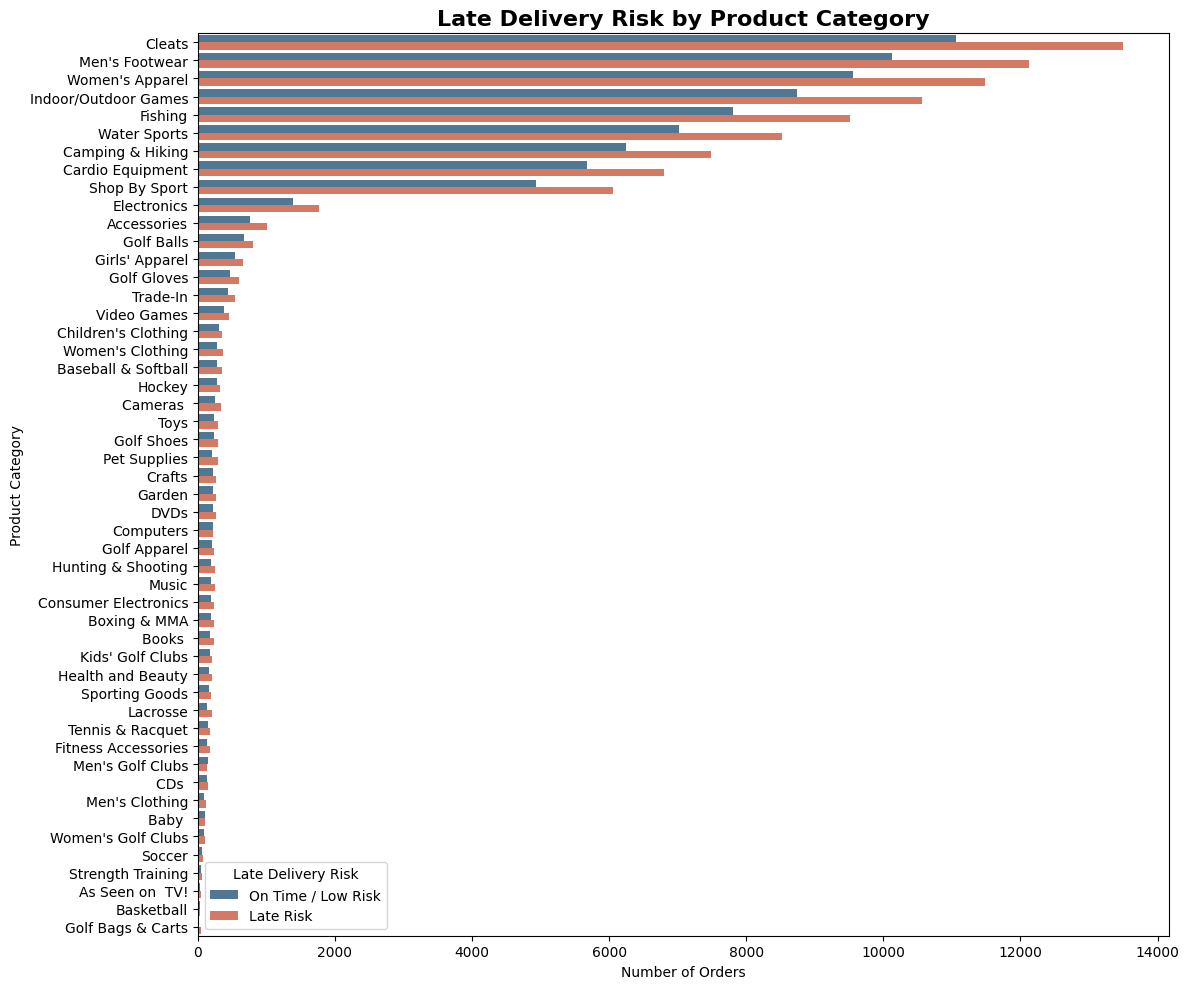

In [17]:
# Late Delivery Risk by Product Category

plt.figure(figsize=(12, 10))

# Sort categories by total number of orders
category_order = (
    data['Category Name']
    .value_counts()
    .index
)

# Clearly contrasting palette
colors = ["#457B9D", "#E76F51"]

sns.countplot(
    y='Category Name',
    hue='Late_delivery_risk',
    data=data,
    order=category_order,
    palette=colors
)

plt.title(
    "Late Delivery Risk by Product Category",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Orders")
plt.ylabel("Product Category")

plt.legend(
    title="Late Delivery Risk",
    labels=["On Time / Low Risk", "Late Risk"]
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# LATE DELIVERY RISK BY PRODUCT CATEGORY - COUNT & PERCENTAGE
# ============================================================

# Count of orders by category and late delivery risk
category_counts = pd.crosstab(
    data['Category Name'],
    data['Late_delivery_risk']
)

# Rename columns
category_counts = category_counts.rename(
    columns={
        0: 'On Time / Low Risk',
        1: 'Late Risk'
    }
)

# Total orders per category
category_counts['Total Orders'] = (
    category_counts['On Time / Low Risk']
    + category_counts['Late Risk']
)

# Calculate percentages
category_counts['Late Risk %'] = (
    category_counts['Late Risk']
    / category_counts['Total Orders']
    * 100
)

category_counts['On Time / Low Risk %'] = (
    category_counts['On Time / Low Risk']
    / category_counts['Total Orders']
    * 100
)

# Sort by total number of orders
category_counts = category_counts.sort_values(
    'Total Orders',
    ascending=False
)

# Round percentages
category_counts[
    ['Late Risk %', 'On Time / Low Risk %']
] = category_counts[
    ['Late Risk %', 'On Time / Low Risk %']
].round(2)

# Display
print(category_counts)

Late_delivery_risk    On Time / Low Risk  Late Risk  Total Orders  \
Category Name                                                       
Cleats                             11055      13496         24551   
Men's Footwear                     10125      12121         22246   
Women's Apparel                     9559      11476         21035   
Indoor/Outdoor Games                8733      10565         19298   
Fishing                             7809       9516         17325   
Water Sports                        7023       8517         15540   
Camping & Hiking                    6242       7487         13729   
Cardio Equipment                    5682       6805         12487   
Shop By Sport                       4926       6058         10984   
Electronics                         1386       1770          3156   
Accessories                          766       1014          1780   
Golf Balls                           670        805          1475   
Girls' Apparel                    



* **Late-delivery risk is widespread:** Most product categories have late-risk rates between **53% and 57%**, indicating that late deliveries are not concentrated in only a few categories.
* **High-volume categories drive the largest number of late orders:** **Cleats (13,496)**, **Men's Footwear (12,121)**, **Women's Apparel (11,476)**, **Indoor/Outdoor Games (10,565)** and **Fishing (9,516)** record the highest numbers of late-risk orders.
* **Highest late-risk percentage:** **Golf Bags & Carts** has the highest rate at **68.85%**, but it has only **61 total orders**, so its high percentage should be interpreted cautiously.
* Among categories with more substantial volumes, **Lacrosse (60.06%)**, **Pet Supplies (58.94%)**, **Cameras (58.11%)**, and **Music (57.14%)** show comparatively higher late-risk rates.
* **Lowest late-risk percentage:** **Men's Golf Clubs (47.70%)** is the only category below 50%, with **135 late-risk orders out of 283**.
* **Overall implication:** High-volume categories such as **Cleats and Men's Footwear** should be prioritized for operational improvement because even moderate risk percentages translate into thousands of late orders.


#**TREE BASED MODELLING APPROACH**

## **DATA PREPROCESSING**

In [19]:
df=data.copy()

In [20]:
# CONVERT TO DATETIME
data['order date (DateOrders)'] = pd.to_datetime(data['order date (DateOrders)'])
data['shipping date (DateOrders)'] = pd.to_datetime(data['shipping date (DateOrders)'])



# ORDER DATE FEATURES
data["Order Year"] = data["order date (DateOrders)"].dt.year
data["Order Month"] = data["order date (DateOrders)"].dt.month
data["Order Month Name"] = data["order date (DateOrders)"].dt.month_name()
data["Order Day"] = data["order date (DateOrders)"].dt.day
data["Order Day of Week"] = data["order date (DateOrders)"].dt.day_name()


# SHIPPING DATE FEATURES
data["Shipping Year"] = data["shipping date (DateOrders)"].dt.year
data["Shipping Month"] = data["shipping date (DateOrders)"].dt.month
data["Shipping Month Name"] = data["shipping date (DateOrders)"].dt.month_name()
data["Shipping Day"] = data["shipping date (DateOrders)"].dt.day
data["Shipping Day of Week"] = data["shipping date (DateOrders)"].dt.day_name()


data["Order Year-Month"] = (data["order date (DateOrders)"].dt.to_period("M").astype(str))
data["Shipping Year-Month"] = (data["order date (DateOrders)"].dt.to_period("M").astype(str))

###**Handling the missing values**

In [21]:
#checking missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


We will drop Product Description since all the values are null values and also drop Order Zipcode as more than 85% of the values are null values

In [22]:
df.drop(['Product Description','Order Zipcode'],axis=1,inplace=True)

Since there is only single entry for the missing Cusomer Last Name,the missing values will be left as such for now

In [23]:
df[df['Customer Zipcode'].isna()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
35704,DEBIT,2,1,66.379997,189.660004,Late delivery,1,65,Consumer Electronics,CA,...,Auvernia-Ródano-Alpes,COMPLETE,1352,65,http://images.acmesports.sports/Industrial+con...,Industrial consumer electronics,252.880005,0,11/4/2017 18:31,First Class
46440,PAYMENT,4,4,10.910000,38.959999,Shipping on time,0,75,Video Games,CA,...,Capital Nacional,PENDING_PAYMENT,1362,75,http://images.acmesports.sports/Fighting+video...,Fighting video games,39.750000,0,12/14/2017 15:18,Standard Class
82511,DEBIT,4,4,59.990002,299.959992,Shipping on time,0,63,Children's Clothing,CA,...,Inglaterra,COMPLETE,1350,63,http://images.acmesports.sports/Children+heaters,Children's heaters,357.100006,0,10/30/2017 0:29,Standard Class


The missing values cannot be directly handled since the  values that lies in the column Customer State is the Customer Zipcodes and the values in the Customer City is the Customer State names.We have to rearrange this and then handle the missing values in the column Customer City

In [24]:
# Find Customer IDs with missing zipcodes
missing_zip_ids = df.loc[
    df["Customer Zipcode"].isna(),
    "Customer Id"
].unique()

# Display all records for those customers
df[df["Customer Id"].isin(missing_zip_ids)][
    [
        "Customer Id",
        "Customer City",
        "Customer State",
        "Customer Zipcode",
        "Order Id"
    ]
].sort_values("Customer Id")

,Customer Id,Customer City,Customer State,Customer Zipcode,Order Id
82511,14046,CA,91732,NaN,70493
35704,14577,CA,95758,NaN,71024
46440,17171,CA,95758,NaN,73618


In [25]:
#taking the value from the Customer State Column" to the "Customer Zipcode" column
mask = df["Customer Zipcode"].isna()

df.loc[mask, "Customer Zipcode"] = (df.loc[mask, "Customer State"].astype(float))

#changing the "Customer State" with the "Customer City" value
df.loc[mask, "Customer State"] = df.loc[mask, "Customer City"]

In [26]:
# Customer IDs with incorrect Customer City
customer_ids = [14046, 14577, 17171]

# Fill Customer City using the mode of City for the same State + Zipcode
for idx in df[df["Customer Id"].isin(customer_ids)].index:

    state = df.loc[idx, "Customer State"]
    zipcode = df.loc[idx, "Customer Zipcode"]

    # Find the most common city for the same state and zipcode
    city_mode = (
        df.loc[
            (df["Customer State"] == state) &
            (df["Customer Zipcode"] == zipcode) &
            (~df["Customer Id"].isin(customer_ids)),   # exclude the incorrect rows
            "Customer City"
        ]
        .mode()
    )

    if not city_mode.empty:
        df.loc[idx, "Customer City"] = city_mode.iloc[0]

In [27]:
df[df["Customer Id"].isin([14046, 14577, 17171])]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
35704,DEBIT,2,1,66.379997,189.660004,Late delivery,1,65,Consumer Electronics,Elk Grove,...,Auvernia-Ródano-Alpes,COMPLETE,1352,65,http://images.acmesports.sports/Industrial+con...,Industrial consumer electronics,252.880005,0,11/4/2017 18:31,First Class
46440,PAYMENT,4,4,10.910000,38.959999,Shipping on time,0,75,Video Games,Elk Grove,...,Capital Nacional,PENDING_PAYMENT,1362,75,http://images.acmesports.sports/Fighting+video...,Fighting video games,39.750000,0,12/14/2017 15:18,Standard Class
82511,DEBIT,4,4,59.990002,299.959992,Shipping on time,0,63,Children's Clothing,El Monte,...,Inglaterra,COMPLETE,1350,63,http://images.acmesports.sports/Children+heaters,Children's heaters,357.100006,0,10/30/2017 0:29,Standard Class


In [28]:
df['Customer Country'].value_counts()

,count
Customer Country,
EE. UU.,111146
Puerto Rico,69373


In [29]:
df['Customer State'].value_counts()

,count
Customer State,
PR,69373
CA,29226
NY,11327
TX,9103
IL,7631
FL,5456
OH,4095
PA,3824
MI,3804


In [30]:
df['Customer City'].unique()

array(['Caguas', 'San Jose', 'Los Angeles', 'Tonawanda', 'Miami',
       'San Ramon', 'Freeport', 'Salinas', 'Peabody', 'Canovanas',
       'Paramount', 'Mount Prospect', 'Long Beach', 'Rancho Cordova',
       'Billings', 'Wilkes Barre', 'Roseville', 'Bellflower', 'Wheaton',
       'Detroit', 'Dallas', 'Carlisle', 'Newark', 'Panorama City',
       'Atlanta', 'Fremont', 'Rochester', 'Bayamon', 'Guayama',
       'Juana Diaz', 'Fort Washington', 'Bakersfield', 'Corona',
       'Cincinnati', 'Germantown', 'Carrollton', 'Houston', 'Ewa Beach',
       'Lakewood', 'Rome', 'Vista', 'Fort Worth', 'Fond Du Lac',
       'Philadelphia', 'Ontario', 'Oviedo', 'Buffalo', 'Honolulu',
       'Oceanside', 'North Tonawanda', 'Clovis', 'Jamaica',
       'Granite City', 'Medford', 'Pomona', 'Tempe', 'Santa Ana', 'York',
       'Aurora', 'Simi Valley', 'Silver Spring', 'Saint Paul',
       'San Antonio', 'Bronx', 'Greenville', 'Morristown', 'San Diego',
       'Oxnard', 'Albuquerque', 'Amarillo', 'Lutz', 'B

###**Feature Selection**

In [31]:
# CONVERT TO DATETIME
df['order date (DateOrders)']    = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])



# ORDER DATE FEATURES
df["Order Year"]          = df["order date (DateOrders)"].dt.year
df["Order Month"]         = df["order date (DateOrders)"].dt.month
df["Order Month Name"]    = df["order date (DateOrders)"].dt.month_name()
df["Order Day"]           = df["order date (DateOrders)"].dt.day
df["Order Day of Week"]   = df["order date (DateOrders)"].dt.day_name()


# SHIPPING DATE FEATURES
df["Shipping Year"]          = df["shipping date (DateOrders)"].dt.year
df["Shipping Month"]         = df["shipping date (DateOrders)"].dt.month
df["Shipping Month Name"]    = df["shipping date (DateOrders)"].dt.month_name()
df["Shipping Day"]           = df["shipping date (DateOrders)"].dt.day
df["Shipping Day of Week"]   = df["shipping date (DateOrders)"].dt.day_name()


df["Order Year-Month"]    = (df["order date (DateOrders)"].dt.to_period("M").astype(str))
df["Shipping Year-Month"] = (df["order date (DateOrders)"].dt.to_period("M").astype(str))

In [32]:
df1=df.copy()

In [33]:
# UNIQUE VALUE COUNT FOR EACH COLUMN
unique_counts = (df1.nunique(dropna=False).sort_values())

display(unique_counts)

,0
Customer Password,1
Customer Email,1
Product Status,1
Late_delivery_risk,2
Customer Country,2
...,...
Benefit per order,21998
shipping date (DateOrders),63701
order date (DateOrders),65752
Order Id,65752


In [34]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Image',
       'Product Na

In [35]:
# COLUMNS TO DROP
drop_cols = [

    # -----------------------------------------------------
    # Personal / Sensitive Information
    # -----------------------------------------------------
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",

    # -----------------------------------------------------
    # Unique Identifiers
    # -----------------------------------------------------
    "Customer Id",
    "Order Customer Id",
    "Order Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",

    # -----------------------------------------------------
    # Duplicate ID Columns
    # -----------------------------------------------------
    "Category Id",
    "Department Id",
    "Product Category Id",

    # -----------------------------------------------------
    # Non-tabular / Unusable Feature
    # -----------------------------------------------------
    "Product Image",

    # -----------------------------------------------------
    # Original Date Columns
    # (Already converted into date features)
    # -----------------------------------------------------
    "order date (DateOrders)",
    "shipping date (DateOrders)",

    # -----------------------------------------------------
    # Duplicate Date Features
    # -----------------------------------------------------
    "Order Month Name",
    "Shipping Month Name",
    "Order Year-Month",
    "Shipping Year-Month",

    # -----------------------------------------------------
    # Location Details
    # -----------------------------------------------------
    'Latitude',
    'Longitude'
]

# DROP COLUMNS
df1 = df1.drop(columns=drop_cols)
print("Shape after dropping columns:", df1.shape)

Shape after dropping columns: (180519, 40)


In [36]:
# CHECK EQUIVALENT COLUMNS
column_pairs = [
    ("Benefit per order", "Order Profit Per Order"),
    ("Sales per customer", "Order Item Total"),
    ("Product Price", "Order Item Product Price")
]

for col1, col2 in column_pairs:

    exact_match = df1[col1].equals(df1[col2])

    close_match = np.isclose(
        df1[col1],
        df1[col2],
        atol=1e-6
    ).all()


    print(f"{col1}  ==  {col2}")
    print(f"Exact Match       : {exact_match}")
    print(f"Numerically Equal : {close_match}")

    if not close_match:
        mismatch = df1.loc[
            ~np.isclose(df1[col1], df1[col2], atol=1e-6),
            [col1, col2]
        ]
        print(f"Number of mismatches: {len(mismatch)}")
        display(mismatch.head())

Benefit per order  ==  Order Profit Per Order
Exact Match       : True
Numerically Equal : True
Sales per customer  ==  Order Item Total
Exact Match       : True
Numerically Equal : True
Product Price  ==  Order Item Product Price
Exact Match       : True
Numerically Equal : True


In [37]:
#dropping the columns "Order Profit Per Order","Order Item Total""Order Item Product Price"
df1.drop(['Benefit per order','Sales per customer','Order Item Product Price'],axis=1,inplace=True)

In [38]:
#dropping the column "Delivery Status" & "Days for shipping (real)" inorder to avoid the data leakage
df1.drop(['Delivery Status','Days for shipping (real)'],axis=1,inplace=True)

In [39]:
df1['Product Status'].value_counts()

,count
Product Status,
0,180519


In [40]:
df1.drop("Product Status",axis=1,inplace=True)

####Analyisng the Shipping Date columns

In [41]:
# Group by Shipping Month
shipping_month_summary = df.groupby('Shipping Month')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Deliveries='sum',
    Late_Delivery_Rate='mean'
).reset_index()
shipping_month_summary['Late_Delivery_Rate (%)'] = (shipping_month_summary['Late_Delivery_Rate'] * 100).round(2)

# Group by Shipping Day of Week
shipping_dow_summary = df.groupby('Shipping Day of Week')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Deliveries='sum',
    Late_Delivery_Rate='mean'
).reset_index()
shipping_dow_summary['Late_Delivery_Rate (%)'] = (shipping_dow_summary['Late_Delivery_Rate'] * 100).round(2)

# Group by Shipping Year
shipping_year_summary = df.groupby('Shipping Year')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Deliveries='sum',
    Late_Delivery_Rate='mean'
).reset_index()
shipping_year_summary['Late_Delivery_Rate (%)'] = (shipping_year_summary['Late_Delivery_Rate'] * 100).round(2)

# Display results
print("--- Late Delivery Rate by Shipping Month ---")
print(shipping_month_summary[['Shipping Month', 'Total_Orders', 'Late_Delivery_Rate (%)']])

print("\n--- Late Delivery Rate by Shipping Day of Week ---")
print(shipping_dow_summary[['Shipping Day of Week', 'Total_Orders', 'Late_Delivery_Rate (%)']])

print("\n--- Late Delivery Rate by Shipping Year ---")
print(shipping_year_summary[['Shipping Year', 'Total_Orders', 'Late_Delivery_Rate (%)']])

--- Late Delivery Rate by Shipping Month ---
    Shipping Month  Total_Orders  Late_Delivery_Rate (%)
0                1         17404                   54.13
1                2         14831                   54.80
2                3         15886                   55.51
3                4         15451                   54.05
4                5         15843                   54.88
5                6         15282                   54.86
6                7         15954                   54.34
7                8         15789                   55.23
8                9         15539                   55.54
9               10         13293                   54.92
10              11         12476                   54.41
11              12         12771                   55.38

--- Late Delivery Rate by Shipping Day of Week ---
  Shipping Day of Week  Total_Orders  Late_Delivery_Rate (%)
0               Friday         25670                   55.30
1               Monday         25923    

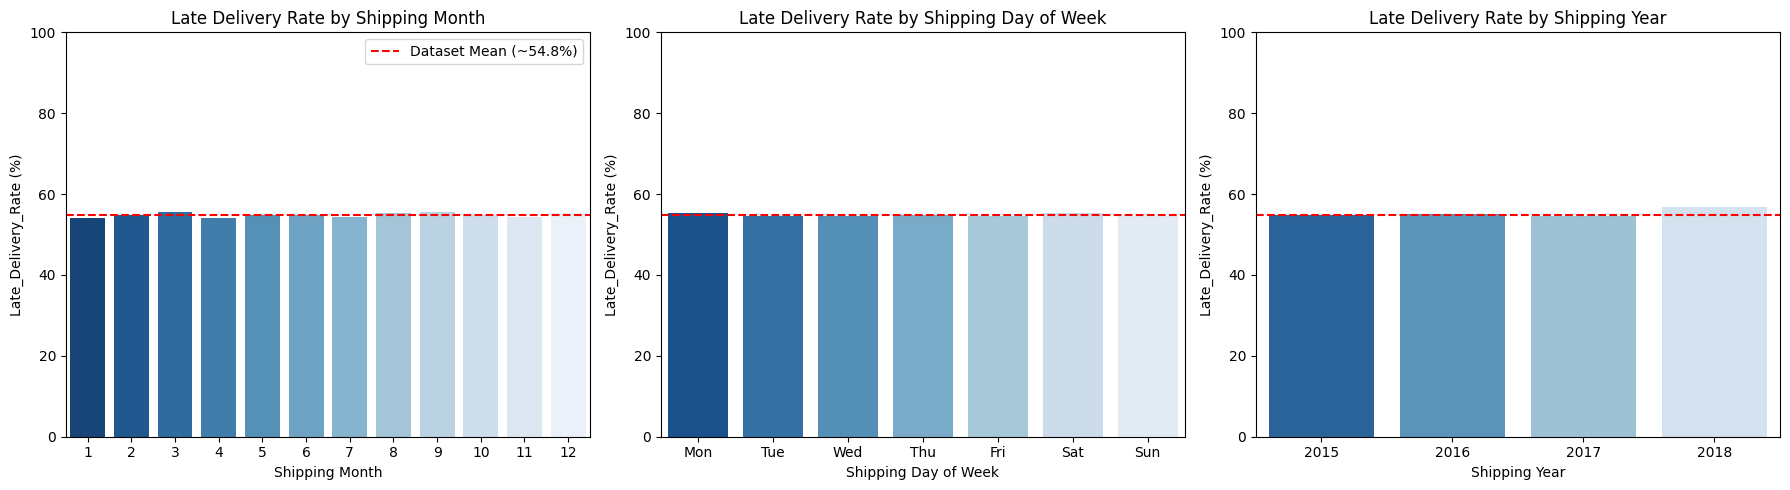

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Shipping Month
sns.barplot(
    data=shipping_month_summary,
    x='Shipping Month',
    y='Late_Delivery_Rate (%)',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Late Delivery Rate by Shipping Month')
axes[0].set_ylim(0, 100)
axes[0].axhline(54.8, color='red', linestyle='--', label='Dataset Mean (~54.8%)')
axes[0].legend()

# Plot 2: Shipping Day of Week
sns.barplot(
    data=shipping_dow_summary,
    x='Shipping Day of Week',
    y='Late_Delivery_Rate (%)',
    ax=axes[1],
    palette='Blues_r'
)
axes[1].set_title('Late Delivery Rate by Shipping Day of Week')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylim(0, 100)
axes[1].axhline(54.8, color='red', linestyle='--', label='Dataset Mean (~54.8%)')

# Plot 3: Shipping Year
sns.barplot(
    data=shipping_year_summary,
    x='Shipping Year',
    y='Late_Delivery_Rate (%)',
    ax=axes[2],
    palette='Blues_r'
)
axes[2].set_title('Late Delivery Rate by Shipping Year')
axes[2].set_ylim(0, 100)
axes[2].axhline(54.8, color='red', linestyle='--', label='Dataset Mean (~54.8%)')

plt.tight_layout()
plt.show()

It is evident that any particular shipping date/period have the effect on late_delivery_risk.Therefore we can drop the columns realted to the shipping date  

In [43]:
df1.drop(['Shipping Year', 'Shipping Month','Shipping Day', 'Shipping Day of Week'],axis=1,inplace =True)

In [44]:
df1.shape

(180519, 30)

###**Feature Relationship Analysis**

In [45]:
checks = {
    "Sales = Product Price × Quantity":
        np.isclose(
            df1["Product Price"] * df1["Order Item Quantity"],
            df1["Sales"]
        ),

    "Order Total = Sales − Discount":
        np.isclose(
            df1["Sales"] - df1["Order Item Discount"],
            df1["Order Item Total"],
            atol=0.01
        )

}

for name, result in checks.items():
    print(f"\n{name}")
    print(f"Passed : {result.sum()}")
    print(f"Failed : {(~result).sum()}")

    if (~result).sum() > 0:
        print("\nSample failed rows:")
        display(
            df1.loc[
                ~result,
                [
                    "Product Price",
                    "Order Item Quantity",
                    "Sales",
                    "Order Item Discount",
                    "Product Price",
                ]
            ].head()
        )


Sales = Product Price × Quantity
Passed : 180519
Failed : 0

Order Total = Sales − Discount
Passed : 180519
Failed : 0


In [46]:
# ============================================================
# LOGICAL RELATIONSHIP CHECKS
# ============================================================

checks = {

    # --------------------------------------------------------
    # 1. SALES
    # Sales = Product Price × Order Item Quantity
    # --------------------------------------------------------

    "Sales = Product Price × Order Item Quantity":

        np.isclose(
            df1["Product Price"] *
            df1["Order Item Quantity"],

            df1["Sales"],

            atol=0.01
        ),


    # --------------------------------------------------------
    # 2. ORDER ITEM DISCOUNT RATE
    # Discount Rate = Discount / Sales
    # --------------------------------------------------------

    "Discount Rate = Order Item Discount / Sales":

        np.isclose(
            df1["Order Item Discount"] /
            df1["Sales"].replace(0, np.nan),

            df1["Order Item Discount Rate"],

            atol=0.0001,

            equal_nan=True
        ),


    # --------------------------------------------------------
    # 3. ORDER ITEM TOTAL
    # Order Item Total = Sales − Discount
    # --------------------------------------------------------

    "Order Item Total = Sales − Order Item Discount":

        np.isclose(
            df1["Sales"] -
            df1["Order Item Discount"],

            df1["Order Item Total"],

            atol=0.01
        ),

    # --------------------------------------------------------
    # 4. ORDER ITEM PROFIT RATIO
    #
    # Profit Ratio = Order Profit Per Order / Sales
    #
    # This is an empirical check against the dataset.
    # --------------------------------------------------------

    "Profit Ratio = Order Profit Per Order / Product Price":

        np.isclose(
            df1["Order Profit Per Order"] /
            df1["Product Price"].replace(0, np.nan),

            df1["Order Item Profit Ratio"],

            atol=0.0001,

            equal_nan=True
        )
}


# ============================================================
# PRINT RESULTS
# ============================================================

for name, result in checks.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Passed : {result.sum()}")
    print(f"Failed : {(~result).sum()}")


    # --------------------------------------------------------
    # SHOW SAMPLE FAILED ROWS
    # --------------------------------------------------------

    if (~result).sum() > 0:

        print("\nSample failed rows:")

        display(
            df1.loc[
                ~result,
                [
                    "Order Profit Per Order",
                    "Order Profit Per Order",
                    "Order Item Profit Ratio",
                    "Sales",
                    "Product Price",
                    "Order Item Quantity",
                    "Order Item Discount",
                    "Order Item Discount Rate",
                    "Order Item Total"
                ]
            ].head()
        )



Sales = Product Price × Order Item Quantity
Passed : 180519
Failed : 0

Discount Rate = Order Item Discount / Sales
Passed : 169376
Failed : 11143

Sample failed rows:


,Order Profit Per Order,Order Profit Per Order,Order Item Profit Ratio,Sales,Product Price,Order Item Quantity,Order Item Discount,Order Item Discount Rate,Order Item Total
2,-247.779999,-247.779999,-0.80,327.750000,327.750000,1,18.030001,0.06,309.720001
20,154.860001,154.860001,0.50,327.750000,327.750000,1,18.030001,0.06,309.720001
38,35.000000,35.000000,0.11,327.750000,327.750000,1,18.030001,0.06,309.720001
77,49.320000,49.320000,0.29,179.970001,59.990002,3,9.900000,0.06,170.070007
94,68.589996,68.589996,0.36,199.949997,39.990002,5,11.000000,0.06,188.949997



Order Item Total = Sales − Order Item Discount
Passed : 180519
Failed : 0

Profit Ratio = Order Profit Per Order / Product Price
Passed : 4638
Failed : 175881

Sample failed rows:


,Order Profit Per Order,Order Profit Per Order,Order Item Profit Ratio,Sales,Product Price,Order Item Quantity,Order Item Discount,Order Item Discount Rate,Order Item Total
0,91.250000,91.250000,0.29,327.75,327.75,1,13.110000,0.04,314.640015
1,-249.089996,-249.089996,-0.80,327.75,327.75,1,16.389999,0.05,311.359985
2,-247.779999,-247.779999,-0.80,327.75,327.75,1,18.030001,0.06,309.720001
3,22.860001,22.860001,0.08,327.75,327.75,1,22.940001,0.07,304.809998
4,134.210007,134.210007,0.45,327.75,327.75,1,29.500000,0.09,298.250000


In [47]:

# CHECK PRODUCT → PRICE CONSISTENCY
product_price_check = (df.groupby("Product Name")["Product Price"].nunique())

# Products having more than one price
multiple_price_products = (product_price_check[product_price_check > 1])
print("PRODUCT PRICE CONSISTENCY CHECK")
print(
    f"\nTotal unique products: "
    f"{df['Product Name'].nunique()}")
print(
    f"Products with exactly one price: "
    f"{(product_price_check == 1).sum()}")

print(
    f"Products with multiple prices: "
    f"{(product_price_check > 1).sum()}")


# DISPLAY PROBLEMATIC PRODUCTS


if len(multiple_price_products) > 0:

    print("\nProducts having multiple prices:")
    print(
        multiple_price_products
        .sort_values(ascending=False)
        .to_string()
    )

    print("\nDetailed price values:")

    problematic_products = (
        df[
            df["Product Name"].isin(
                multiple_price_products.index
            )
        ]
        .groupby("Product Name")["Product Price"]
        .unique()
    )

    print(
        problematic_products.to_string()
    )

else:

    print(
        "\n✓ Every product has exactly one Product Price."
    )

PRODUCT PRICE CONSISTENCY CHECK

Total unique products: 118
Products with exactly one price: 118
Products with multiple prices: 0

✓ Every product has exactly one Product Price.


In [48]:
# Check Product → Category and Department consistency

check = df.groupby("Product Name")[
    ["Category Name", "Department Name"]
].nunique()

# Products having more than one Category or Department
inconsistent = check[
    (check["Category Name"] > 1) |
    (check["Department Name"] > 1)
]

print("Total unique products:", df["Product Name"].nunique())
print("Products with inconsistent mapping:", len(inconsistent))

if len(inconsistent) == 0:
    print("\n✓ Every product has exactly one Category Name and Department Name.")
else:
    print("\n⚠️ Some products have multiple Category/Department values.")
    print(inconsistent)

Total unique products: 118
Products with inconsistent mapping: 0

✓ Every product has exactly one Category Name and Department Name.


###**Feature Engineering**

In [49]:
df1.shape

(180519, 30)

In [50]:
df1.columns

Index(['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country',
       'Customer Segment', 'Customer State', 'Customer Zipcode',
       'Department Name', 'Market', 'Order City', 'Order Country',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'Shipping Mode', 'Order Year', 'Order Month', 'Order Day',
       'Order Day of Week'],
      dtype='object')

In [51]:
char_columns = df1.select_dtypes(include=['object']).columns
print(char_columns)

Index(['Type', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Segment', 'Customer State', 'Department Name', 'Market',
       'Order City', 'Order Country', 'Order Region', 'Order State',
       'Order Status', 'Product Name', 'Shipping Mode', 'Order Day of Week'],
      dtype='object')


In [52]:
#Consolidate date columns into operational deltas
df1['is_weekend_order'] = df1['Order Day of Week'].isin([5, 6]).astype(int)

In [53]:
#Geo-spatial Logic
df1['is_cross_border'] = (df1['Customer Country'] != df1['Order Country']).astype(int)
#df1["Origin_Destination"] = (df1["Order City"].astype(str)+ "_"+ df1["Customer City"].astype(str))

####Analaying the geographical locations of the order and customer and its relation to the Late_Delivery_Risk


In [54]:
df1['Customer Zipcode'] = df1['Customer Zipcode'].astype(str)

In [55]:
# 1. DESTINATION ANALYSIS (Order Country & Order City)

# Top Destination Countries
top_order_countries = df1['Order Country'].value_counts().head(10).index
dest_country_summary = df1[df1['Order Country'].isin(top_order_countries)].groupby('Order Country')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()

# Top Destination State
top_order_cities = df1['Order State'].value_counts().head(10).index
dest_state_summary = df1[df1['Order State'].isin(top_order_cities)].groupby('Order State')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()

# Top Destination Cities
top_order_cities = df1['Order City'].value_counts().head(10).index
dest_city_summary = df1[df1['Order City'].isin(top_order_cities)].groupby('Order City')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()

print("=== Order Country Analysis ===")
print(dest_country_summary.sort_values(by='Late_Rate_Pct', ascending=False))

print("=== Order State Analysis ===")
print(dest_state_summary.sort_values(by='Late_Rate_Pct', ascending=False))

print("\n=== Order City Analysis ===")
print(dest_city_summary.sort_values(by='Late_Rate_Pct', ascending=False))

# 2. ORIGIN ANALYSIS (Customer Country Sustomer State , Customer City & Customer Zipcode)


# Origin Country Summary
origin_country_summary = df1.groupby('Customer Country')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()

# Top Origin State
top_customer_cities = df1['Customer State'].value_counts().head(10).index
origin_state_summary = df1[df1['Customer State'].isin(top_customer_cities)].groupby('Customer State')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()


# Top Origin Cities
top_customer_cities = df1['Customer City'].value_counts().head(10).index
origin_city_summary = df1[df1['Customer City'].isin(top_customer_cities)].groupby('Customer City')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()

# Top Origin Zipcode
top_customer_cities = df1['Customer Zipcode'].value_counts().head(10).index
origin_zipcode_summary = df1[df1['Customer Zipcode'].isin(top_customer_cities)].groupby('Customer Zipcode')['Late_delivery_risk'].agg(
    Total_Orders='count',
    Late_Rate_Pct=lambda x: (x.mean() * 100).round(2)
).reset_index()

print("\n=== Customer Country Analysis ===")
print(origin_country_summary)

print("\n===  Customer State Analysis ===")
print(origin_state_summary.sort_values(by='Late_Rate_Pct', ascending=False))

print("\n===  Customer City Analysis ===")
print(origin_city_summary.sort_values(by='Late_Rate_Pct', ascending=False))

print("\n===  Customer Zipcode Analysis ===")
print(origin_zipcode_summary.sort_values(by='Late_Rate_Pct', ascending=False))

=== Order Country Analysis ===
    Order Country  Total_Orders  Late_Rate_Pct
0        Alemania          9564          56.28
6           India          4783          56.12
5         Francia         13222          55.52
4  Estados Unidos         24840          55.03
8          México         13172          55.01
1       Australia          8497          54.29
3           China          5758          54.24
2          Brasil          7987          54.23
7          Italia          4989          53.56
9     Reino Unido          7302          53.45
=== Order State Analysis ===
                   Order State  Total_Orders  Late_Rate_Pct
5                   Nueva York          2753          57.90
1             Distrito Federal          2559          56.86
9                        Texas          2446          56.66
7                 San Salvador          3055          56.53
3              Isla de Francia          4580          56.51
6  Renania del Norte-Westfalia          3303          56.01
8  

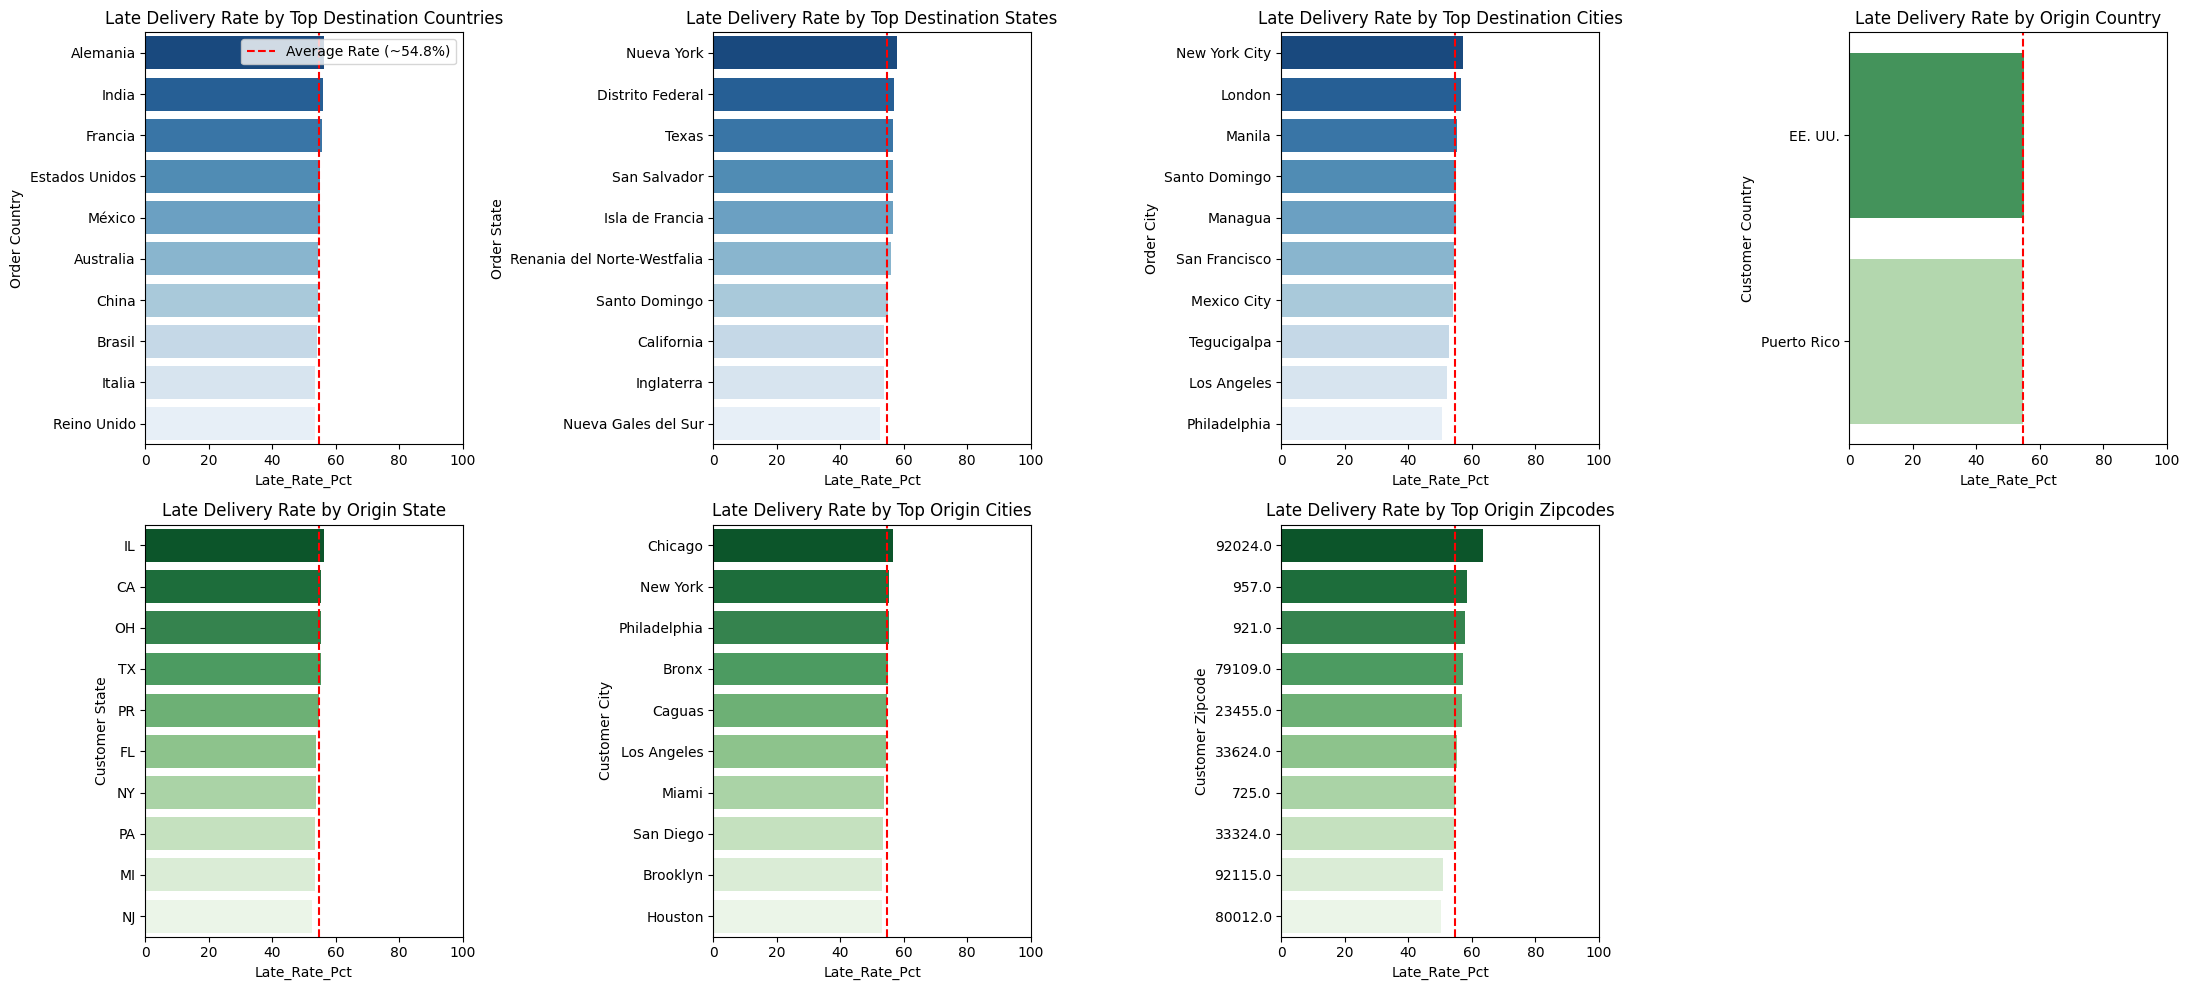

In [56]:
# Updated grid dimensions: 2 rows x 4 columns
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# ---------------------------------------------------------
# ROW 0: DESTINATION GEOGRAPHIES
# ---------------------------------------------------------

# Plot 1: Top Destination Countries (Row 0, Col 0)
sns.barplot(
    data=dest_country_summary.sort_values("Late_Rate_Pct", ascending=False),
    x="Late_Rate_Pct",
    y="Order Country",
    ax=axes[0, 0],
    palette="Blues_r",
)
axes[0, 0].set_title("Late Delivery Rate by Top Destination Countries")
axes[0, 0].set_xlim(0, 100)
axes[0, 0].axvline(
    54.8, color="red", linestyle="--", label="Average Rate (~54.8%)"
)
axes[0, 0].legend()

# Plot 2: Top Destination States (Row 0, Col 1) [NEW PLOT]
sns.barplot(
    data=dest_state_summary.sort_values("Late_Rate_Pct", ascending=False),
    x="Late_Rate_Pct",
    y="Order State",
    ax=axes[0, 1],
    palette="Blues_r",
)
axes[0, 1].set_title("Late Delivery Rate by Top Destination States")
axes[0, 1].set_xlim(0, 100)
axes[0, 1].axvline(54.8, color="red", linestyle="--")

# Plot 3: Top Destination Cities (Row 0, Col 2)
sns.barplot(
    data=dest_city_summary.sort_values("Late_Rate_Pct", ascending=False),
    x="Late_Rate_Pct",
    y="Order City",
    ax=axes[0, 2],
    palette="Blues_r",
)
axes[0, 2].set_title("Late Delivery Rate by Top Destination Cities")
axes[0, 2].set_xlim(0, 100)
axes[0, 2].axvline(54.8, color="red", linestyle="--")

# Plot 4: Origin Country (Row 0, Col 3)
sns.barplot(
    data=origin_country_summary,
    x="Late_Rate_Pct",
    y="Customer Country",
    ax=axes[0, 3],
    palette="Greens_r",
)
axes[0, 3].set_title("Late Delivery Rate by Origin Country")
axes[0, 3].set_xlim(0, 100)
axes[0, 3].axvline(54.8, color="red", linestyle="--")


# ---------------------------------------------------------
# ROW 1: ORIGIN GEOGRAPHIES
# ---------------------------------------------------------

# Plot 5: Origin State (Row 1, Col 0)
sns.barplot(
    data=origin_state_summary.sort_values("Late_Rate_Pct", ascending=False),
    x="Late_Rate_Pct",
    y="Customer State",
    ax=axes[1, 0],
    palette="Greens_r",
)
axes[1, 0].set_title("Late Delivery Rate by Origin State")
axes[1, 0].set_xlim(0, 100)
axes[1, 0].axvline(54.8, color="red", linestyle="--")

# Plot 6: Top Origin Cities (Row 1, Col 1)
sns.barplot(
    data=origin_city_summary.sort_values("Late_Rate_Pct", ascending=False),
    x="Late_Rate_Pct",
    y="Customer City",
    ax=axes[1, 1],
    palette="Greens_r",
)
axes[1, 1].set_title("Late Delivery Rate by Top Origin Cities")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].axvline(54.8, color="red", linestyle="--")

# Plot 7: Top Origin Zipcodes (Row 1, Col 2)
sns.barplot(
    data=origin_zipcode_summary.sort_values("Late_Rate_Pct", ascending=False),
    x="Late_Rate_Pct",
    y="Customer Zipcode",
    ax=axes[1, 2],
    palette="Greens_r",
)
axes[1, 2].set_title("Late Delivery Rate by Top Origin Zipcodes")
axes[1, 2].set_xlim(0, 100)
axes[1, 2].axvline(54.8, color="red", linestyle="--")

# Hide unused plot (Row 1, Col 3)
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

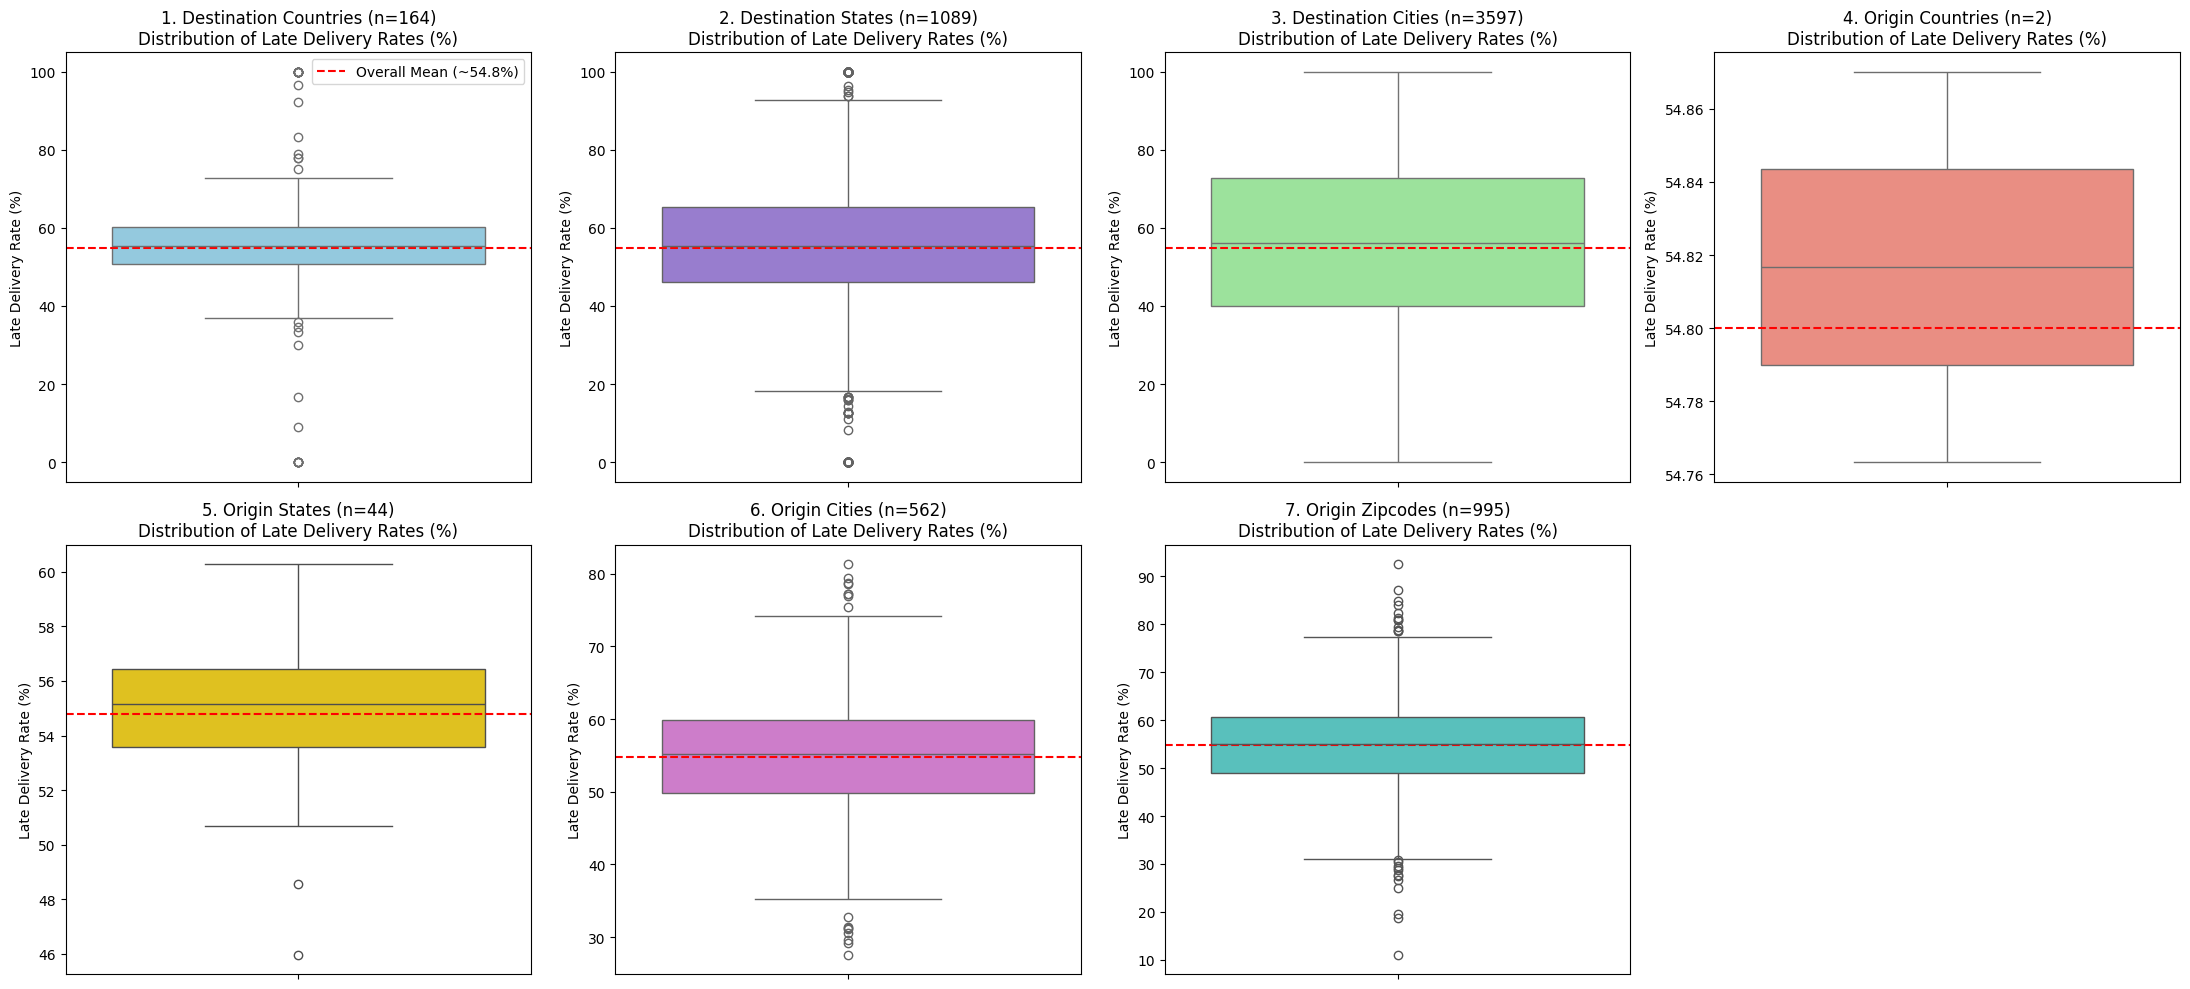

In [57]:
# Ensure zipcode is treated as a string type
df["Customer Zipcode"] = df["Customer Zipcode"].astype(str)

# ---------------------------------------------------------
# Calculate Summaries (Late Delivery Rates per Group)
# ---------------------------------------------------------
dest_country = (
    df.groupby("Order Country")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

dest_state = (
    df.groupby("Order State")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

dest_city = (
    df.groupby("Order City")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

origin_country = (
    df.groupby("Customer Country")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

origin_state = (
    df.groupby("Customer State")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

origin_city = (
    df.groupby("Customer City")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

origin_zipcode = (
    df.groupby("Customer Zipcode")["Late_delivery_risk"]
    .agg(Late_Rate_Pct=lambda x: (x.mean() * 100))
    .reset_index()
)

# ---------------------------------------------------------
# Create 2x4 Boxplot Grid
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# Plot 1: Destination Countries (Row 0, Col 0)
sns.boxplot(y=dest_country["Late_Rate_Pct"], ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title(
    f"1. Destination Countries (n={len(dest_country)})\nDistribution of Late Delivery Rates (%)"
)
axes[0, 0].set_ylabel("Late Delivery Rate (%)")
axes[0, 0].axhline(
    54.8, color="red", linestyle="--", label="Overall Mean (~54.8%)"
)
axes[0, 0].legend()

# Plot 2: Destination States (Row 0, Col 1) [NEW PLOT]
sns.boxplot(y=dest_state["Late_Rate_Pct"], ax=axes[0, 1], color="mediumpurple")
axes[0, 1].set_title(
    f"2. Destination States (n={len(dest_state)})\nDistribution of Late Delivery Rates (%)"
)
axes[0, 1].set_ylabel("Late Delivery Rate (%)")
axes[0, 1].axhline(54.8, color="red", linestyle="--")

# Plot 3: Destination Cities (Row 0, Col 2)
sns.boxplot(y=dest_city["Late_Rate_Pct"], ax=axes[0, 2], color="lightgreen")
axes[0, 2].set_title(
    f"3. Destination Cities (n={len(dest_city)})\nDistribution of Late Delivery Rates (%)"
)
axes[0, 2].set_ylabel("Late Delivery Rate (%)")
axes[0, 2].axhline(54.8, color="red", linestyle="--")

# Plot 4: Origin Countries (Row 0, Col 3)
sns.boxplot(y=origin_country["Late_Rate_Pct"], ax=axes[0, 3], color="salmon")
axes[0, 3].set_title(
    f"4. Origin Countries (n={len(origin_country)})\nDistribution of Late Delivery Rates (%)"
)
axes[0, 3].set_ylabel("Late Delivery Rate (%)")
axes[0, 3].axhline(54.8, color="red", linestyle="--")

# Plot 5: Origin States (Row 1, Col 0)
sns.boxplot(y=origin_state["Late_Rate_Pct"], ax=axes[1, 0], color="gold")
axes[1, 0].set_title(
    f"5. Origin States (n={len(origin_state)})\nDistribution of Late Delivery Rates (%)"
)
axes[1, 0].set_ylabel("Late Delivery Rate (%)")
axes[1, 0].axhline(54.8, color="red", linestyle="--")

# Plot 6: Origin Cities (Row 1, Col 1)
sns.boxplot(y=origin_city["Late_Rate_Pct"], ax=axes[1, 1], color="orchid")
axes[1, 1].set_title(
    f"6. Origin Cities (n={len(origin_city)})\nDistribution of Late Delivery Rates (%)"
)
axes[1, 1].set_ylabel("Late Delivery Rate (%)")
axes[1, 1].axhline(54.8, color="red", linestyle="--")

# Plot 7: Origin Zipcodes (Row 1, Col 2)
sns.boxplot(
    y=origin_zipcode["Late_Rate_Pct"], ax=axes[1, 2], color="mediumturquoise"
)
axes[1, 2].set_title(
    f"7. Origin Zipcodes (n={len(origin_zipcode)})\nDistribution of Late Delivery Rates (%)"
)
axes[1, 2].set_ylabel("Late Delivery Rate (%)")
axes[1, 2].axhline(54.8, color="red", linestyle="--")

# Plot 8: Unused (Row 1, Col 3)
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

In [58]:
dest_city_summary.describe()

,Total_Orders,Late_Rate_Pct
count,10.000000,10.000000
mean,1637.400000,54.351000
std,370.371345,2.040781
min,1187.000000,50.460000
25%,1321.750000,53.150000
50%,1583.000000,54.710000
75%,1829.500000,55.362500
max,2211.000000,57.270000


In [59]:
dest_state_summary.describe()

,Total_Orders,Late_Rate_Pct
count,10.000000,10.000000
mean,3496.500000,55.546000
std,1469.178852,1.729324
min,2211.000000,52.450000
25%,2474.250000,54.087500
50%,2904.000000,56.260000
75%,4260.750000,56.627500
max,6722.000000,57.900000


In [60]:
origin_state_summary.describe()

,Total_Orders,Late_Rate_Pct
count,10.000000,10.000000
mean,14703.000000,54.448000
std,20710.171006,1.141741
min,3191.000000,52.550000
25%,3891.750000,53.665000
50%,6543.500000,54.340000
75%,10771.000000,55.237500
max,69373.000000,56.390000


In [61]:
def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


cat_cols = [
    "Type","Category Name","Customer City","Customer Segment","Department Name",
    "Market","Order Country","Order Region","Order Status","Shipping Mode",
    'Customer Zipcode','Customer State','Customer Country','Order City','Order State'
]

# Calculate Cramér's V for each categorical column against the Target
target_associations = {}
for col in cat_cols:
    target_associations[col] = cramers_v(df1[col], df1["Late_delivery_risk"])

target_corr_df = pd.DataFrame(
    list(target_associations.items()), columns=["Feature", "Cramers_V_Target"]
).sort_values(by="Cramers_V_Target", ascending=False)

print("=== Categorical Feature Association with Target ===")
print(target_corr_df)

=== Categorical Feature Association with Target ===
             Feature  Cramers_V_Target
9      Shipping Mode          0.457073
13        Order City          0.242314
8       Order Status          0.233552
14       Order State          0.133109
10  Customer Zipcode          0.113049
2      Customer City          0.085453
0               Type          0.078094
6      Order Country          0.048065
11    Customer State          0.017741
7       Order Region          0.017124
5             Market          0.005076
3   Customer Segment          0.000000
4    Department Name          0.000000
1      Category Name          0.000000
12  Customer Country          0.000000


Drop the columns Customer Zipcode,Customer State,Customer Country and Order City based on these columns late delivery risk rate and cardinality

In [62]:
df1.drop(['Customer Zipcode','Customer State','Customer Country','Order City'],axis=1,inplace =True)

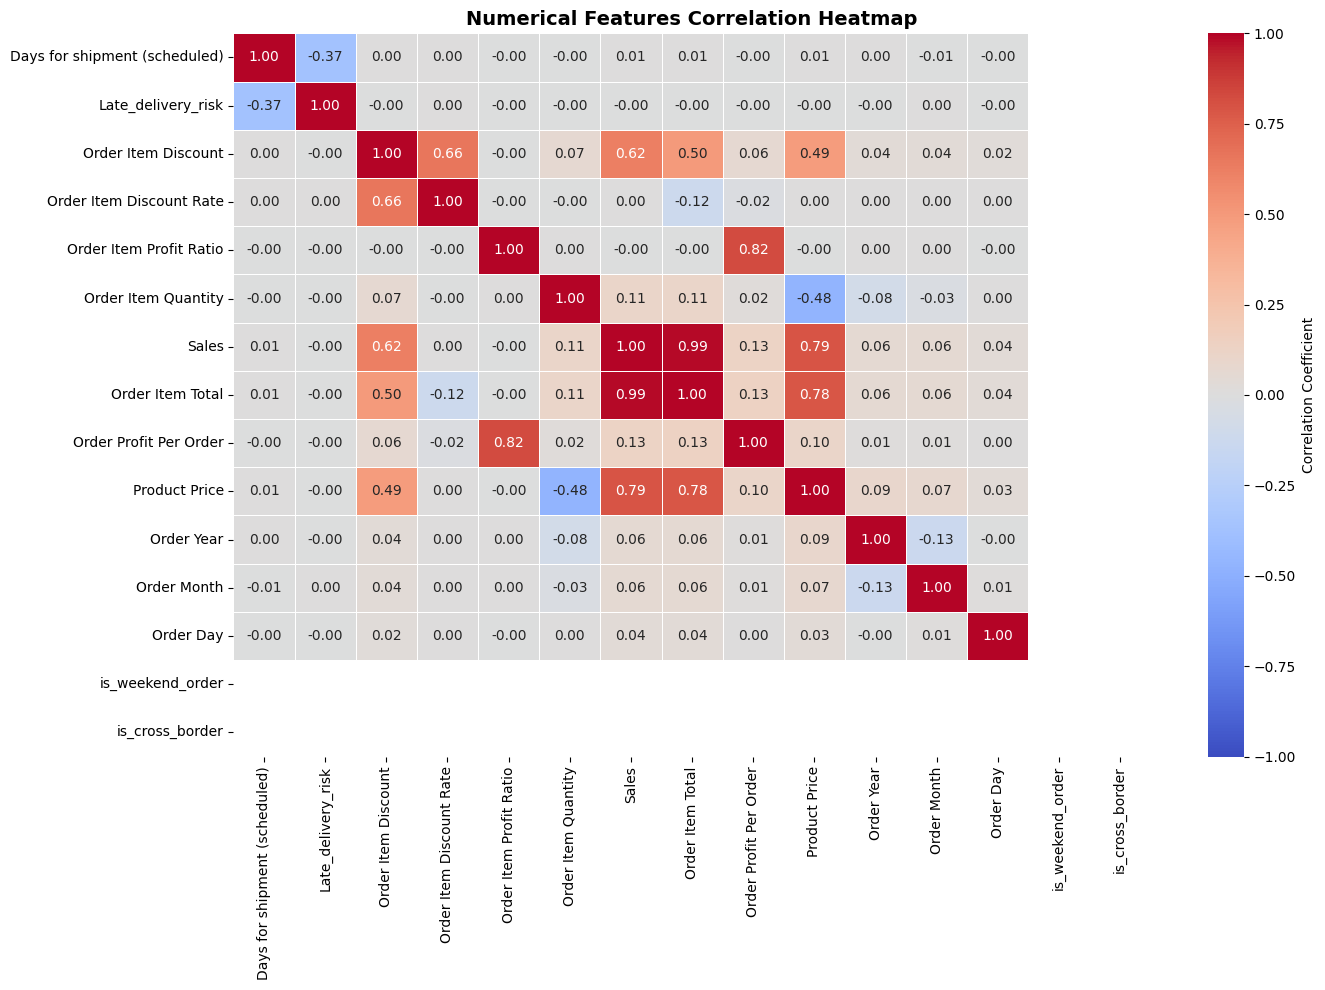

In [63]:
# Select numerical columns
num_cols = df1.select_dtypes(include=[np.number]).columns

# Compute Pearson correlation matrix
corr_matrix = df1[num_cols].corr()

# Plot Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"},
)

plt.title("Numerical Features Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [64]:
# Select numerical columns
num_cols = df1.select_dtypes(include=[np.number]).columns
num_cols = num_cols.drop("Late_delivery_risk")

# Create dataframe containing numerical features
X = df1[num_cols].copy()

# Calculate VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort by VIF
vif_df = vif_df.sort_values(by="VIF", ascending=False)

vif_df

,Feature,VIF
5,Sales,7.563475e+09
6,Order Item Total,6.229579e+09
1,Order Item Discount,2.054540e+08
13,is_cross_border,6.096316e+06
8,Product Price,1.714282e+01
4,Order Item Quantity,6.533015e+00
2,Order Item Discount Rate,3.378689e+00
7,Order Profit Per Order,3.296020e+00
3,Order Item Profit Ratio,3.237302e+00
9,Order Year,1.031674e+00


In [65]:
#removing the Order Item Profit Ratio and Order Item Discount Rate
df1.drop(['Order Item Profit Ratio','Order Item Discount Rate'],axis=1,inplace =True)

In [66]:
df1.shape

(180519, 26)

###**Feature Encoding**


In [67]:
df1.columns

Index(['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Segment', 'Department Name',
       'Market', 'Order Country', 'Order Item Discount', 'Order Item Quantity',
       'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'Shipping Mode', 'Order Year', 'Order Month', 'Order Day',
       'Order Day of Week', 'is_weekend_order', 'is_cross_border'],
      dtype='object')

In [68]:
char_columns = df1.select_dtypes(include=['object']).columns
print(char_columns)

Index(['Type', 'Category Name', 'Customer City', 'Customer Segment',
       'Department Name', 'Market', 'Order Country', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Shipping Mode',
       'Order Day of Week'],
      dtype='object')


In [69]:
# Get the number of unique values
char_columns = df1.select_dtypes(include=['object']).columns
df1[char_columns].nunique()

,0
Type,4
Category Name,50
Customer City,562
Customer Segment,3
Department Name,11
Market,5
Order Country,164
Order Region,23
Order State,1089
Order Status,9


In [70]:
df_encoded = df1.copy()

In [71]:
# ONE-HOT ENCODING
onehot_cols = [
    "Type",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Status",
    "Shipping Mode",
    "Order Day of Week"
]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_array = encoder.fit_transform(df_encoded[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(onehot_cols),
    index=df_encoded.index
)

# Remove original one-hot columns
df_encoded = df_encoded.drop(columns=onehot_cols)

# Add encoded columns
df_encoded = pd.concat(
    [df1, encoded_df],
    axis=1
)


# FREQUENCY ENCODING
frequency_cols = [
    "Category Name",
    "Customer City",
    "Order Country",
    "Order Region",
    "Order State",
    "Product Name"
]

for col in frequency_cols:
    freq = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freq)

In [72]:
df_encoded.shape

(180519, 69)

In [73]:
# REMOVE ORIGINAL CATEGORICAL COLUMNS
categorical_cols = ["Type","Customer Segment","Department Name","Market","Order Status","Shipping Mode","Order Day of Week"]
df_encoded = df_encoded.drop(columns=categorical_cols)

In [74]:
df_encoded.shape

(180519, 62)

##**MODELLING**

In [75]:
#Splittind data into X and y
X = df_encoded.drop(columns=["Late_delivery_risk"])
y = df_encoded["Late_delivery_risk"]

In [76]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


####1.Random Forest

In [ ]:
# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)

In [ ]:
# Predictions
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
param_grid = {"n_estimators": [100, 200],"max_depth": [None, 10, 20, 30, 40],
              "min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4],
              "max_features": ["sqrt", "log2"],"bootstrap": [True, False]}

In [ ]:
rf = RandomForestClassifier(random_state=42,n_jobs=-1)

In [ ]:
random_search = RandomizedSearchCV(estimator=rf,param_distributions=param_grid,n_iter=10,cv=3,scoring="f1",
                                   random_state=42,n_jobs=-1, verbose=2)

random_search.fit(X_train, y_train)

In [ ]:
results = random_search.cv_results_

for i in range(len(results["params"])):

    print("\n" + "="*80)
    print(f"CHECK {i+1}")
    print("="*80)

    print("Parameters:")
    for parameter, value in results["params"][i].items():
        print(f"  {parameter}: {value}")

    print(f"\nFold 1 F1 Score : {results['split0_test_score'][i]:.4f}")
    print(f"Fold 2 F1 Score : {results['split1_test_score'][i]:.4f}")
    print(f"Fold 3 F1 Score : {results['split2_test_score'][i]:.4f}")

    print(f"Mean F1 Score   : {results['mean_test_score'][i]:.4f}")
    print(f"Std F1 Score    : {results['std_test_score'][i]:.4f}")
    print(f"Rank             : {results['rank_test_score'][i]}")

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

In [ ]:
print("Best CV F1 Score:")
print(random_search.best_score_)

In [ ]:
best_rf = random_search.best_estimator_

In [ ]:
y_pred = best_rf.predict(X_test)

print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall   :", recall_score(y_test, y_pred))
print("Test F1 Score  :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
print("Baseline F1:",
      f1_score(y_test, rf_model.predict(X_test)))

print("Tuned F1:",
      f1_score(y_test, best_rf.predict(X_test)))

####2.XGB Classifier

In [ ]:

xgb_model = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,
                          random_state=42,n_jobs=-1,eval_metric="logloss")

# TRAIN MODEL
xgb_model.fit(X_train, y_train)


# PREDICTION
y_pred = xgb_model.predict(X_test)


# EVALUATION
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost Baseline Performance")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
xgb = XGBClassifier(random_state=42,n_jobs=-1,eval_metric="logloss")


# HYPERPARAMETER SEARCH SPACE

param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 6, 8, 10],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2]
}


# RANDOMIZED SEARCH
random_search_xgb = RandomizedSearchCV(estimator=xgb,param_distributions=param_grid,n_iter=15,
                                       cv=3,scoring="f1",random_state=42,n_jobs=-1,verbose=2)


# FIT
random_search_xgb.fit(X_train, y_train)

In [ ]:
# Print results of all 15 parameter combinations
results = pd.DataFrame(random_search_xgb.cv_results_)

# Select useful columns
results = results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "params"
    ]
].sort_values("rank_test_score")

print(results.to_string(index=False))

In [ ]:
print("Best Parameters:")
print(random_search_xgb.best_params_)

In [ ]:
print("Best CV F1 Score:")
print(random_search_xgb.best_score_)

In [ ]:
best_xgb = random_search_xgb.best_estimator_

In [ ]:
y_pred_xgb = best_xgb.predict(X_test)

In [ ]:
print("Tuned XGBoost Performance")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test,y_pred_xgb))




print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_xgb))


####3.LightGBM Classifier

In [ ]:
# Create a separate dataframe for LightGBM
df_lgbm = df1.copy()

In [ ]:
# Target variable
y = df_lgbm["Late_delivery_risk"]

# Features
X = df_lgbm.drop(columns=["Late_delivery_risk"])

In [ ]:
categorical_cols = [
    "Type",
    "Category Name",
    "Customer City",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Order State",
    "Order Status",
    "Product Name",
    "Shipping Mode",
    "Order Day of Week"
]

In [ ]:
for col in categorical_cols:
    X[col] = X[col].astype("category")

In [ ]:
X.dtypes.value_counts()

In [ ]:
#train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

**Creating Artifact for App**

In [ ]:

# SAVE CATEGORICAL VALUES FROM TRAINING DATA


categorical_columns = [
    "Type",
    "Category Name",
    "Customer City",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Order State",
    "Order Status",
    "Product Name",
    "Shipping Mode",
    "Order Day of Week"
]

category_values = {}

for col in categorical_columns:

    values = (
        X_train[col]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    values.sort()

    category_values[col] = values


# CHECK


for col, values in category_values.items():
  print( f"{col}: {len(values)} unique values")

CATEGORY_VALUES_PATH = "/content/category_values.pkl"
joblib.dump(category_values,CATEGORY_VALUES_PATH)
print("Saved:",CATEGORY_VALUES_PATH)


**Modelling**

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lgbm_model = LGBMClassifier(n_estimators=100,learning_rate=0.1,max_depth=-1,random_state=42,n_jobs=-1)

In [ ]:
lgbm_model.fit(X_train,y_train,categorical_feature=categorical_cols)

In [ ]:
y_pred = lgbm_model.predict(X_test)
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
# BASE LIGHTGBM MODEL
lgbm = LGBMClassifier(objective="binary",random_state=42,n_jobs=-1,verbosity=-1)



# HYPERPARAMETER SEARCH SPACE
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [-1, 5, 10, 15, 20],
    "num_leaves": [15, 31, 50, 70, 100],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [ ]:
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_lgbm.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

In [ ]:
results_df = pd.DataFrame(random_search_lgbm.cv_results_)

results_display = results_df[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "param_num_leaves",
        "param_min_child_samples",
        "param_subsample",
        "param_colsample_bytree"
    ]
].sort_values("rank_test_score")

display(results_display)

In [ ]:
print("Best Parameters:")
print(random_search_lgbm.best_params_)

In [ ]:
print("Best CV F1 Score:")
print(random_search_lgbm.best_score_)

In [ ]:
best_lgbm = random_search_lgbm.best_estimator_

In [ ]:
#evaluate
y_pred = best_lgbm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
baseline_pred = lgbm_model.predict(X_test)
tuned_pred = best_lgbm.predict(X_test)

print("Baseline F1:",
      f1_score(y_test, baseline_pred))

print("Tuned F1:",
      f1_score(y_test, tuned_pred))

In [ ]:
print("===== FINAL MODEL INFORMATION =====")

print("\nModel:")
print(best_lgbm)

print("\nNumber of features:")
print(len(best_lgbm.feature_name_))

print("\nFeature names:")
print(best_lgbm.feature_name_)

print("\nCategorical columns:")
print(categorical_cols)

print("\nX_train shape:")
print(X_train.shape)

print("\nX_test shape:")
print(X_test.shape)

In [ ]:
print("===== FINAL DATA TYPES =====")
print(X_train.dtypes)

**Saving the Model**

In [ ]:
#Create the export directory

MODEL_DIR = "/content/model_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Model artifact directory:", MODEL_DIR)

In [ ]:
#Save the LightGBM model
import joblib

joblib.dump(best_lgbm,os.path.join(MODEL_DIR, "late_delivery_lgbm.pkl"))
print("LightGBM model saved.")

In [ ]:
#Save the feature columns
feature_columns = best_lgbm.feature_name_
joblib.dump(feature_columns,os.path.join(MODEL_DIR, "feature_columns.pkl"))
print("Feature columns saved.")
print(feature_columns)

In [ ]:
#Save the categorical columns
joblib.dump(categorical_cols,os.path.join(MODEL_DIR, "categorical_columns.pkl"))
print("Categorical columns saved.")
print(categorical_cols)

In [ ]:
print(os.listdir(MODEL_DIR))

In [ ]:
#verifying whether the
loaded_model = joblib.load(
    os.path.join(MODEL_DIR, "late_delivery_lgbm.pkl")
)

loaded_features = joblib.load(
    os.path.join(MODEL_DIR, "feature_columns.pkl")
)

loaded_categorical = joblib.load(
    os.path.join(MODEL_DIR, "categorical_columns.pkl")
)

print("Model loaded successfully.")
print("Number of features:", len(loaded_features))
print("Categorical features:", len(loaded_categorical))

#**LINEAR OR DISTANCE BASED MODELLING APPROACH**

#SVM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import warnings
warnings.filterwarnings("ignore")


In [ ]:
df1=data.copy()

In [ ]:
missing = df1.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("\nColumns with missing values:")
print(missing)

In [ ]:

# Drop columns that are unrecoverable (>40% missing)
HIGH_NULL_THRESHOLD = 0.40

high_null_cols = (
    missing[missing / len(df) > HIGH_NULL_THRESHOLD]
    .index
    .tolist()
)

print("\nDropping high-null columns:", high_null_cols)

df1 = df1.drop(
    columns=high_null_cols,
    errors="ignore"
)

# Drop PII (not useful for modeling, and shouldn't be in the pipeline anyway)
pii_cols = [
    "Customer Password",
    "Customer Email",
    "Customer Fname",
    "Customer Lname"
]

print("\nPII columns removed:")

for c in pii_cols:
    if c in df1.columns:
        print(c)

df1 = df1.drop(
    columns=[c for c in pii_cols if c in df1.columns],
    errors="ignore"
)


In [ ]:
# Handle remaining small amounts of missing data
# Customer Zipcode: mode is a placeholder value (~37% of rows share one zip) -> drop instead of impute
if "Customer Zipcode" in df1.columns:

    print(
        "\nCustomer Zipcode missing before:",
        df1["Customer Zipcode"].isnull().sum()
    )

    df1 = df1.dropna(
        subset=["Customer Zipcode"]
    )

    print(
        "Customer Zipcode missing after:",
        df1["Customer Zipcode"].isnull().sum()
    )


In [ ]:
 #Any other remaining numeric/categorical nulls -> median/mode
num_cols = df1.select_dtypes(include=[np.number]).columns
cat_cols = df1.select_dtypes(include=["object"]).columns
for c in num_cols:
    if df1[c].isnull().any():
        df1[c] = df1[c].fillna(df1[c].median())
for c in cat_cols:
    if df1[c].isnull().any():
        df1[c] = df1[c].fillna(df1[c].mode()[0])

print("Remaining nulls:", df1.isnull().sum().sum())


In [ ]:

df1["order date (DateOrders)"] = pd.to_datetime(df1["order date (DateOrders)"])
df1["shipping date (DateOrders)"] = pd.to_datetime(df1["shipping date (DateOrders)"])

df1["Order Year"] = df1["order date (DateOrders)"].dt.year
df1["Order Month"] = df1["order date (DateOrders)"].dt.month
df1["Order Day of Week"] = df1["order date (DateOrders)"].dt.dayofweek
df1["Order Year-Month"] = df1["order date (DateOrders)"].dt.to_period("M").astype(str)


In [ ]:
# Business-rule check: shipped before ordered should never happen
bad_dates = df1["shipping date (DateOrders)"] < df1["order date (DateOrders)"]
print("Rows shipped before ordered (invalid):", bad_dates.sum())
df1 = df1[~bad_dates]



In [ ]:
# Target variable
if "Late_delivery_risk" not in df1.columns:

    df1["Late_delivery_risk"] = (
        df1["Days for shipping (real)"]
        >
        df1["Days for shipment (scheduled)"]
    ).astype(int)


print("\nLate delivery risk distribution:")

print(
    df1["Late_delivery_risk"]
    .value_counts()
)

print("\nLate delivery risk percentage:")

print(
    df1["Late_delivery_risk"]
    .value_counts(normalize=True)
)



In [ ]:
# Drop leakage / ID columns
leakage_or_id_cols = [

    "Delivery Status",

    "Days for shipping (real)",

    "order date (DateOrders)",
    "shipping date (DateOrders)",

    "Order Id",
    "Order Item Id",
    "Order Customer Id",
    "Customer Id",

    "Product Card Id",
    "Order Item Cardprod Id",

    "Product Category Id",
    "Category Id",
    "Department Id",

    "Customer Street",
    "Product Image",

    "Order Zipcode",
]


df1 = df1.drop(
    columns=[
        c for c in leakage_or_id_cols
        if c in df.columns
    ],
    errors="ignore"
)


In [ ]:
constant_cols = [
    c
    for c in df1.columns
    if df1[c].nunique(dropna=False) <= 1
]

print("\nConstant columns:")

for c in constant_cols:
    print(
        c,
        "->",
        df1[c].unique()
    )


df1 = df1.drop(
    columns=constant_cols,
    errors="ignore"
)

In [ ]:
# Business-rule outlier checks (real data errors, not statistical outliers)
invalid_checks = {
    "Negative Sales": df1["Sales"] < 0,
    "Non-positive Quantity": df1["Order Item Quantity"] <= 0,
    "Negative Product Price": df1["Order Item Product Price"] < 0,
}
for name, mask in invalid_checks.items():
    print(f"{name}: {mask.sum()} rows")
    df1 = df1[~mask]


#Outlier Handling

In [ ]:
# Statistical outlier detection (IQR) + capping, CALCULATED PER CATEGORY
# Global IQR would compare a laptop's price against a phone case's price and
# treat them as the same "normal range" -- meaningless, since different product
# categories have genuinely different typical prices/sales/profit. Instead, we
# compute IQR bounds separately within each Category Name, so "outlier" means
# unusual FOR THAT PRODUCT TYPE, not unusual across the whole catalog.
outlier_candidates = [
    c for c in ["Sales", "Order Item Quantity", "Benefit per order",
                "Sales per customer", "Order Item Discount",
                "Order Item Discount Rate", "Order Item Product Price",
                "Order Item Profit Ratio"]
    if c in df1.columns
]

GROUP_COL = "Category Name" if "Category Name" in df1.columns else None
MIN_GROUP_SIZE = 10  # too few rows in a category to trust a boundary -> skip capping

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# --- Reporting: how many outliers per column, using GLOBAL bounds just for a
# before/after sense of scale (capping itself is done per-category below) ---
outlier_summary = {}
for col in outlier_candidates:
    low, high = iqr_bounds(df1[col])
    n_out = ((df1[col] < low) | (df1[col] > high)).sum()
    outlier_summary[col] = {"lower": low, "upper": high,
                             "n_outliers": n_out,
                             "pct_outliers": round(n_out / len(df) * 100, 2)}
outlier_df = pd.DataFrame(outlier_summary).T
print("Global IQR bounds (reporting only):")
print(outlier_df)

# --- Actual capping: per-category IQR, so a computer is judged against other
# computers and a phone case against other phone cases ---
def cap_within_group(group, col, k=1.5):
    if len(group) < MIN_GROUP_SIZE:
        return group  # not enough rows in this category to trust a boundary
    low, high = iqr_bounds(group[col], k=k)
    group[col] = group[col].clip(lower=low, upper=high)
    return group

if GROUP_COL:
    for col in outlier_candidates:
        before = df1[col].copy()
        df1 = df1.groupby(GROUP_COL, group_keys=False).apply(
            lambda g, c=col: cap_within_group(g, c)
        )
        n_changed = (df1[col] != before).sum()
        print(f"{col}: capped {n_changed} rows (per-category IQR)")
else:
    # Fallback if Category Name isn't available -- global capping
    print("Category Name not found, falling back to global IQR capping")
    for col in outlier_candidates:
        low, high = iqr_bounds(df[col])
        df1[col] = df1[col].clip(lower=low, upper=high)


In [ ]:
#Feature engineering — tailored for Logistic Regression
# Logistic Regression only learns a straight-line combination of whatever
# features it's given -- it can't discover ratios or interactions on its own
# the way tree models can. So we build them explicitly here, using the
# ORIGINAL (pre-log-transform) scale, since ratios of already-log-transformed
# values wouldn't mean the same thing.

# 1. Discount impact: how much of the price was discounted, as a ratio
df1["Discount_to_Price_Ratio"] = df1["Order Item Discount"] / (df1["Order Item Product Price"] + 1)

# 2. High-discount flag: was this order discounted more than the typical order
df1["High_Discount_Flag"] = (
    df1["Order Item Discount Rate"] > df1["Order Item Discount Rate"].median()
).astype(int)

# 3. Order value tier -- substitute for "shipment weight" (no weight column
# exists in this dataset), using order value as a proxy for shipment scale
df1["Order_Value_Tier"] = pd.cut(
    df1["Order Item Total"],
    bins=[-np.inf, 100, 500, np.inf],
    labels=["Low", "Medium", "High"]
)

# 4. Quantity x Price interaction -- LR can't infer this on its own, so we
# give it directly; tree models can find this split themselves, LR cannot
df1["Total_Line_Value"] = df1["Order Item Quantity"] * df1["Order Item Product Price"]

# 5. Tight scheduled-shipping-window flag -- a clean, interpretable risk signal
df1["Tight_Schedule_Flag"] = (df1["Days for shipment (scheduled)"] <= 1).astype(int)

print("New engineered features added:",
      ["Discount_to_Price_Ratio", "High_Discount_Flag", "Order_Value_Tier",
       "Total_Line_Value", "Tight_Schedule_Flag"])



In [ ]:
# Skew check + log-transform for heavily right-skewed, positive-only columns
# StandardScaler assumes roughly normal data. Sales, Sales per customer,
# Order Item Discount, and Order Item Product Price are all strongly right-skewed
# (skew ~2.9-3.2) in this dataset -- log1p compresses the long tail so the
# distribution is closer to normal BEFORE any scaler sees it.
# Benefit per order / Order Item Profit Ratio are skewed too but contain negative
# values, so log1p doesn't apply -- those are handled with RobustScaler instead,
# in the scaling step below.
log_transform_cols = [c for c in ["Sales", "Sales per customer",
                                    "Order Item Discount", "Order Item Product Price",
                                    "Total_Line_Value"]
                       if c in df1.columns]

print("Skew before log-transform:")
print(df1[log_transform_cols].skew())

for col in log_transform_cols:
    df1[col] = np.log1p(df1[col].clip(lower=0))  # clip guards against any stray negatives

print("\nSkew after log-transform:")
print(df1[log_transform_cols].skew())

# Columns that will use RobustScaler later (median/IQR-based, not mean/std-based)
# because they have negative values and heavy skew that log1p can't fix
robust_scale_cols = [c for c in ["Benefit per order", "Order Item Profit Ratio"]
                      if c in df1.columns]

# Remaining numeric columns with mild/no skew -> plain StandardScaler is fine
standard_scale_cols_source = [c for c in ["Order Item Discount Rate",
                                            "Days for shipment (scheduled)",
                                            "Order Item Quantity", "Discount_to_Price_Ratio"]
                               if c in df1.columns]


In [ ]:
#Feature / target split

target = "Late_delivery_risk"

X = df1.drop(
    columns=[target]
)

y = df1[target]


print(
    "\nFeature shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


print(
    "\nTrain shape:",
    X_train.shape
)

print(
    "Test shape:",
    X_test.shape
)



In [ ]:
#Identify categorical columns

candidate_cat_cols = (

    X_train
    .select_dtypes(
        include=[
            "object",
            "category"
        ]
    )
    .columns
    .tolist()
)


cardinality = (
    X_train[
        candidate_cat_cols
    ].nunique()
)


CARDINALITY_THRESHOLD = 15


low_card_cols = (

    cardinality[
        cardinality <=
        CARDINALITY_THRESHOLD
    ]
    .index
    .tolist()
)


high_card_cols = (

    cardinality[
        cardinality >
        CARDINALITY_THRESHOLD
    ]
    .index
    .tolist()
)


print(
    "\nLow-cardinality columns:"
)

print(
    low_card_cols
)


print(
    "\nHigh-cardinality columns:"
)

print(
    high_card_cols
)


In [ ]:
#Encode categorical columns
X_train = X_train.copy()

X_test = X_test.copy()


# One-hot encoding

onehot = OneHotEncoder(

    handle_unknown="ignore",

    sparse_output=False,

    drop="first"
)


if low_card_cols:

    X_train_onehot = onehot.fit_transform(
        X_train[low_card_cols]
    )

    X_test_onehot = onehot.transform(
        X_test[low_card_cols]
    )

    onehot_cols = (
        onehot
        .get_feature_names_out(
            low_card_cols
        )
    )

    X_train_onehot = pd.DataFrame(

        X_train_onehot,

        columns=onehot_cols,

        index=X_train.index
    )

    X_test_onehot = pd.DataFrame(

        X_test_onehot,

        columns=onehot_cols,

        index=X_test.index
    )

else:

    X_train_onehot = pd.DataFrame(
        index=X_train.index
    )

    X_test_onehot = pd.DataFrame(
        index=X_test.index
    )


# Ordinal encoding

ordinal = OrdinalEncoder(

    handle_unknown="use_encoded_value",

    unknown_value=-1
)


if high_card_cols:

    X_train_ordinal = ordinal.fit_transform(
        X_train[high_card_cols]
    )

    X_test_ordinal = ordinal.transform(
        X_test[high_card_cols]
    )

    X_train_ordinal = pd.DataFrame(

        X_train_ordinal,

        columns=high_card_cols,

        index=X_train.index
    )

    X_test_ordinal = pd.DataFrame(

        X_test_ordinal,

        columns=high_card_cols,

        index=X_test.index
    )

else:

    X_train_ordinal = pd.DataFrame(
        index=X_train.index
    )

    X_test_ordinal = pd.DataFrame(
        index=X_test.index
    )


# Remaining numerical columns

remaining_cols = [

    c

    for c in X_train.columns

    if c not in (
        low_card_cols
        +
        high_card_cols
    )
]


X_train_numeric = (
    X_train[remaining_cols]
    .reset_index(drop=True)
)


X_test_numeric = (
    X_test[remaining_cols]
    .reset_index(drop=True)
)


X_train_ordinal = (
    X_train_ordinal
    .reset_index(drop=True)
)


X_test_ordinal = (
    X_test_ordinal
    .reset_index(drop=True)
)


X_train_onehot = (
    X_train_onehot
    .reset_index(drop=True)
)


X_test_onehot = (
    X_test_onehot
    .reset_index(drop=True)
)


# Reassemble

X_train = pd.concat(

    [

        X_train_numeric,

        X_train_ordinal,

        X_train_onehot

    ],

    axis=1
)


X_test = pd.concat(

    [

        X_test_numeric,

        X_test_ordinal,

        X_test_onehot

    ],

    axis=1
)

In [ ]:
#Remove any remaining non-numeric columns

non_numeric = (

    X_train
    .select_dtypes(
        exclude=[np.number, "bool"]
    )
    .columns
    .tolist()
)


if non_numeric:

    print(
        "Dropping remaining non-numeric columns:",
        non_numeric
    )

    X_train = X_train.drop(
        columns=non_numeric,
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=non_numeric,
        errors="ignore"
    )


print(
    "\nPost-encoding train shape:",
    X_train.shape
)

print(
    "Post-encoding test shape:",
    X_test.shape
)

In [ ]:
#Scaling

# SVM is highly sensitive to feature scale.
# Therefore scaling is very important.

robust_cols_present = [

    c

    for c in robust_scale_cols

    if c in X_train.columns
]


standard_cols_present = [

    c

    for c in X_train.columns

    if c not in robust_cols_present
]


robust_scaler = RobustScaler()

standard_scaler = StandardScaler()


# Robust scaling

if robust_cols_present:

    X_train_robust = (
        robust_scaler
        .fit_transform(
            X_train[
                robust_cols_present
            ]
        )
    )

    X_test_robust = (
        robust_scaler
        .transform(
            X_test[
                robust_cols_present
            ]
        )
    )

else:

    X_train_robust = np.empty(
        (len(X_train), 0)
    )

    X_test_robust = np.empty(
        (len(X_test), 0)
    )


# Standard scaling

X_train_standard = (

    standard_scaler

    .fit_transform(
        X_train[
            standard_cols_present
        ]
    )
)


X_test_standard = (

    standard_scaler

    .transform(
        X_test[
            standard_cols_present
        ]
    )
)


# Combine scaled features

X_train_scaled = np.hstack(

    [

        X_train_standard,

        X_train_robust

    ]
)


X_test_scaled = np.hstack(

    [

        X_test_standard,

        X_test_robust

    ]
)


print(
    "\nFinal training matrix:",
    X_train_scaled.shape
)

print(
    "Final testing matrix:",
    X_test_scaled.shape
)


In [ ]:
svm_baseline = LinearSVC(max_iter=5000, random_state=42)  # default C=1.0, class_weight=None
svm_baseline.fit(X_train_scaled, y_train)

y_pred_svm_base = svm_baseline.predict(X_test_scaled)
y_score_svm_base = svm_baseline.decision_function(X_test_scaled)

accuracy_svm_base = accuracy_score(y_test, y_pred_svm_base)
precision_svm_base = precision_score(y_test, y_pred_svm_base)
recall_svm_base = recall_score(y_test, y_pred_svm_base)
f1_svm_base = f1_score(y_test, y_pred_svm_base)
roc_auc_svm_base = roc_auc_score(y_test, y_score_svm_base)

svm_baseline_results = pd.DataFrame([{
    "Model": "SVM (Baseline)",
    "Accuracy": accuracy_svm_base,
    "Precision": precision_svm_base,
    "Recall": recall_svm_base,
    "F1-Score": f1_svm_base,
    "ROC-AUC": roc_auc_svm_base,
}])

display(svm_baseline_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}).hide(axis="index"))

In [ ]:
# ============================================================
# SVM + Hyperparameter Tuning
# ============================================================

print(
    "\nStarting SVM hyperparameter tuning..."
)

# LinearSVC is used instead of SVC(RBF)
# because the dataset is very large (~180k rows).

svm = LinearSVC(
    max_iter=5000,
    random_state=42
)


# ============================================================
# Hyperparameters to tune
# ============================================================

param_grid = {

    "C": [
        0.01,
        0.1,
        1,
        10
    ],

    "class_weight": [
        None,
        "balanced"
    ],

    "loss": [
        "squared_hinge"
    ],

    "penalty": [
        "l2"
    ]
}


# ============================================================
# Grid Search with 3-Fold Cross Validation
# ============================================================

grid_search = GridSearchCV(

    estimator=svm,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=3,

    n_jobs=-1,

    verbose=2

)


grid_search.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# Best Parameters
# ============================================================

print(
    "\nBest SVM parameters:"
)

print(
    grid_search.best_params_
)


# ============================================================
# Best Cross-Validated ROC-AUC
# ============================================================

print(
    "\nBest cross-validated ROC-AUC:"
)

print(
    round(
        grid_search.best_score_,
        4
    )
)


# ============================================================
# Final Tuned SVM Model
# ============================================================

svm_model = (
    grid_search.best_estimator_
)


print(
    "\nFinal tuned SVM model:"
)

print(
    svm_model
)

In [ ]:
# ============================================================
# SVM + Hyperparameter Tuning
# ============================================================

print(
    "\nStarting SVM hyperparameter tuning..."
)

# LinearSVC is used instead of SVC(RBF)
# because the dataset is very large (~180k rows).

svm = LinearSVC(
    max_iter=5000,
    random_state=42
)


# ============================================================
# Hyperparameters to tune
# ============================================================

param_grid = {

    "C": [
        0.01,
        0.1,
        1,
        10
    ],

    "class_weight": [
        None,
        "balanced"
    ],

    "loss": [
        "squared_hinge"
    ],

    "penalty": [
        "l2"
    ]
}


# ============================================================
# Grid Search with 3-Fold Cross Validation
# ============================================================

grid_search = GridSearchCV(

    estimator=svm,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=3,

    n_jobs=-1,

    verbose=2

)


grid_search.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# Best Parameters
# ============================================================

print(
    "\nBest SVM parameters:"
)

print(
    grid_search.best_params_
)


# ============================================================
# Best Cross-Validated ROC-AUC
# ============================================================

print(
    "\nBest cross-validated ROC-AUC:"
)

print(
    round(
        grid_search.best_score_,
        4
    )
)


# ============================================================
# Final Tuned SVM Model
# ============================================================

svm_model = (
    grid_search.best_estimator_
)


print(
    "\nFinal tuned SVM model:"
)

print(
    svm_model
)

In [ ]:
y_pred = svm_model.predict(X_test_scaled)

y_score = svm_model.decision_function(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_score)

print("SVM TEST RESULTS")
print("================")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["On-time", "Late"]
    )
)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On-time", "Late"]
)

disp.plot(cmap="Blues")

plt.title("SVM — Confusion Matrix")
plt.tight_layout()
plt.show()

#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# ============================================================
# Baseline Logistic Regression — default hyperparameters, NO GridSearchCV
# Trained once with LogisticRegression's defaults (C=1.0, class_weight=None,
# penalty="l2") so we can compare against the tuned model later.
# ============================================================

log_reg_baseline = LogisticRegression(max_iter=2000, random_state=42)
log_reg_baseline.fit(X_train_scaled, y_train)

y_pred_lr_base = log_reg_baseline.predict(X_test_scaled)
y_score_lr_base = log_reg_baseline.predict_proba(X_test_scaled)[:, 1]

accuracy_lr_base = accuracy_score(y_test, y_pred_lr_base)
precision_lr_base = precision_score(y_test, y_pred_lr_base)
recall_lr_base = recall_score(y_test, y_pred_lr_base)
f1_lr_base = f1_score(y_test, y_pred_lr_base)
roc_auc_lr_base = roc_auc_score(y_test, y_score_lr_base)

lr_baseline_results = pd.DataFrame([{
    "Model": "Logistic Regression (Baseline)",
    "Accuracy": accuracy_lr_base,
    "Precision": precision_lr_base,
    "Recall": recall_lr_base,
    "F1-Score": f1_lr_base,
    "ROC-AUC": roc_auc_lr_base,
}])

print("LOGISTIC REGRESSION BASELINE RESULTS (before tuning)")
display(lr_baseline_results.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1-Score": "{:.4f}", "ROC-AUC": "{:.4f}"
}).hide(axis="index"))

In [ ]:
log_reg_fixed_weight = LogisticRegression(max_iter=2000, random_state=42)

param_grid_no_balance = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None],   # locked to None, not searched
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_search_nb = GridSearchCV(
    estimator=log_reg_fixed_weight,
    param_grid=param_grid_no_balance,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search_nb.fit(X_train_scaled, y_train)

print("Best params (class_weight forced to None):", grid_search_nb.best_params_)
print("Best cross-validated ROC-AUC:", round(grid_search_nb.best_score_, 4))

log_reg_nb_model = grid_search_nb.best_estimator_

y_pred_nb = log_reg_nb_model.predict(X_test_scaled)
y_score_nb = log_reg_nb_model.predict_proba(X_test_scaled)[:, 1]

print("\nLOGISTIC REGRESSION (class_weight=None, tuned C/penalty) RESULTS")
print(f"Accuracy :  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_score_nb):.4f}")